In [1]:
%load_ext autoreload

In [2]:
%autoreload 2
%aimport sog1_helpers

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import protfasta

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

#plt.rcParams['text.usetex'] = True

plt.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica" #somethings this one doesnt work
plt.rcParams['pdf.fonttype'] = 42

activity_col = "Activity_S3_1"

# 1. Obtain ortholog and NAC family tiles

In [3]:
# Reading in the wt tiles of all sog1 orthologs and nac family tiles
basic_tiles = sog1_helpers.return_activities("Basic", pos_regex = "")
basic_tiles = basic_tiles[~basic_tiles["Description"].str.contains("_")]
basic_tiles["name"] = basic_tiles["Other"].str.split("_").str[0]
basic_tiles["name"] = basic_tiles["name"].str.replace("SOG1", "")
basic_tiles["name"] = basic_tiles["name"].str.strip()
basic_tiles

,Start,End,Description,Other,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end,name
0,1,40,Basic6.1,Q9LR74,MKILPVGSRFCPTDLGLVRLYLRNKVERNQSSFITTMDIH,4770.0,2356.944285,NaN,1.0,NaN,NaN,Q9LR74
1,11,50,Basic6.2,Q9LR74,CPTDLGLVRLYLRNKVERNQSSFITTMDIHQDYPWLLPHV,314.0,3343.355645,1722.872101,2.0,1620.483543,5066.227746,Q9LR74
2,21,60,Basic6.3,Q9LR74,YLRNKVERNQSSFITTMDIHQDYPWLLPHVNNPLFNNNEW,NaN,NaN,NaN,NaN,NaN,NaN,Q9LR74
3,31,70,Basic6.4,Q9LR74,SSFITTMDIHQDYPWLLPHVNNPLFNNNEWYYFVPLTERG,NaN,NaN,NaN,NaN,NaN,NaN,Q9LR74
4,41,80,Basic6.5,Q9LR74,QDYPWLLPHVNNPLFNNNEWYYFVPLTERGGKILSVHRKV,NaN,NaN,NaN,NaN,NaN,NaN,Q9LR74
...,...,...,...,...,...,...,...,...,...,...,...,...
3012,371,410,BasicArTh.38,Q6NQK2,GSQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,2924.0,904.569692,1320.706714,6.0,-416.137023,2225.276406,Q6NQK2
3013,381,420,BasicArTh.39,Q6NQK2,SGSLKDKQPCIADYAHLGPEDFKRDLEECQKIVLDPSNIE,6270.0,666.698396,559.960759,9.0,106.737637,1226.659155,Q6NQK2
3014,391,430,BasicArTh.40,Q6NQK2,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDTPPEFRLS,3263.0,2050.634351,1244.030950,9.0,806.603401,3294.665302,Q6NQK2
3015,401,440,BasicArTh.41,Q6NQK2,DFKRDLEECQKIVLDPSNIELDTPPEFRLSQLEFGSQDSF,712.0,1552.582733,1032.710596,9.0,519.872136,2585.293329,Q6NQK2


In [4]:
basic_tiles["Other"].value_counts()

Other
A4FVP                                                54
MarchantiaPolymorphaSOG1_Lib1                        50
Nelumbonucifera_A0A1U8ABV8_TAIR                      47
S.bicolor_Sobic.010G111800.2.p_Macovei               46
WT_e2fa                                              46
B.distachyon_Bradi1g43840.1.p_Macovei                46
PhyscomitriumPatens_PpSOG1a                          46
Q9SCK6                                               44
B.rapa_Brara.G00896.1.p_Macovei                      42
Q6NQK2                                               42
Nicotianatabacum(tobacco)_A0A1S3X2K2_TAIR            41
G.max_Glyma.10G204700.1.p_Macovei                    40
E.grandis_Eucgr.G02349.1.p_Macovei                   40
V.vinifera peptide_GSVIVT01011954001_Macovei         40
PopulusTrichocarpaSOG1_Lib1                          40
ZeaMays_ACL54469.1                                   39
OryzaSativa_ XP_015640881.1                          39
Amborellatrichopoda_W1NK30_TAIR           

In [5]:
sog1_orthologs = pd.read_csv("../data/sog1_orthologs.csv", sep = "\t")
sog1_orthologs["name"] = sog1_orthologs["Wild type sequences:"].str.split("_").str[0]
sog1_orthologs["name"] = sog1_orthologs["name"].str.replace("SOG1", "")
sog1_orthologs["name"] = sog1_orthologs["name"].str.strip()
ArTh_wt = "".join(pd.read_csv("../data/Sog1_AA_features.csv")["aa"])
sog1_orthologs.loc[15] = {"name" : "Q6NQK2", "Unnamed: 1" : ArTh_wt}
sog1_orthologs

,Wild type sequences:,Unnamed: 1,name
0,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNS...,B.rapa
1,S.bicolor_Sobic.010G111800.2.p_Macovei,MPRRFFFFAVDGSSGQMMTFLYFGFNDKEDMSTVRMKTTWIIDSQR...,S.bicolor
2,E.grandis_Eucgr.G02349.1.p_Macovei,MAGPSWLVDSHRIATKIRSASGASDPEKVKWKSNPTRACPNCQHVI...,E.grandis
3,V.vinifera peptide_GSVIVT01011954001_Macovei,MSWLVDSNRFATKIKNASGTRETERVKWKSNPSRACPNCQHIIDNS...,V.vinifera peptide
4,PopulusTrichocarpaSOG1_Lib1,MAGPWLVDGNRFATKIKSASSASNHERVAWKSDPCKTCPNCHHVID...,PopulusTrichocarpa
5,Nicotianatabacum(tobacco)_A0A1S3X2K2_TAIR,MCYRFRRPSWLVDSKRIATKIKSASGDPGAVNWKSNPTKACPNCQF...,Nicotianatabacum(tobacco)
6,G.max_Glyma.10G204700.1.p_Macovei,MAGPSWLVDKSRIATKIKNVSGTCGKVIWKSNPSRACPSCHHVIDN...,G.max
7,Selaginellamoellendorffii(spikemoss)_D8RBR5_TAIR,MSQAPQDWTGLPAGVKFDPNDKEILDHLAAKIGRGGKPHALIDEFI...,Selaginellamoellendorffii(spikemoss)
8,MarchantiaPolymorphaSOG1_Lib1,MKNRDHRDRWGRFMDQLVRQIDNATHQRNDAYSLAQDDTTALPGLE...,MarchantiaPolymorpha
9,PhyscomitriumPatensSOG1_Lib1,MDRVASNRILGASKLRCDNNAAAHVKLDSFPAGVRFDPSDEELLEH...,PhyscomitriumPatens


In [6]:
orthologs = basic_tiles[basic_tiles["name"].isin(sog1_orthologs["name"])]
orthologs

,Start,End,Description,Other,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end,name
471,1,40,BasicBrRa.1,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCH,4741.0,187.276143,NaN,1.0,NaN,NaN,B.rapa
472,11,50,BasicBrRa.2,B.rapa_Brara.G00896.1.p_Macovei,NRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNSHEVD,NaN,NaN,NaN,NaN,NaN,NaN,B.rapa
473,21,60,BasicBrRa.3,B.rapa_Brara.G00896.1.p_Macovei,SDPCPTVWNTNPTRHCPNCHHVIDNSHEVDDWPGLPRGVK,6219.0,650.731599,NaN,1.0,NaN,NaN,B.rapa
474,31,70,BasicBrRa.4,B.rapa_Brara.G00896.1.p_Macovei,NPTRHCPNCHHVIDNSHEVDDWPGLPRGVKFDPSDPEIIW,4954.0,902.494857,287.599290,4.0,614.895568,1190.094147,B.rapa
475,41,80,BasicBrRa.5,B.rapa_Brara.G00896.1.p_Macovei,HVIDNSHEVDDWPGLPRGVKFDPSDPEIIWHLLAKTGSLG,3090.0,394.336560,NaN,1.0,NaN,NaN,B.rapa
...,...,...,...,...,...,...,...,...,...,...,...,...
3012,371,410,BasicArTh.38,Q6NQK2,GSQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,2924.0,904.569692,1320.706714,6.0,-416.137023,2225.276406,Q6NQK2
3013,381,420,BasicArTh.39,Q6NQK2,SGSLKDKQPCIADYAHLGPEDFKRDLEECQKIVLDPSNIE,6270.0,666.698396,559.960759,9.0,106.737637,1226.659155,Q6NQK2
3014,391,430,BasicArTh.40,Q6NQK2,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDTPPEFRLS,3263.0,2050.634351,1244.030950,9.0,806.603401,3294.665302,Q6NQK2
3015,401,440,BasicArTh.41,Q6NQK2,DFKRDLEECQKIVLDPSNIELDTPPEFRLSQLEFGSQDSF,712.0,1552.582733,1032.710596,9.0,519.872136,2585.293329,Q6NQK2


In [7]:
len(orthologs["Other"].value_counts())

16

In [8]:
nac_fam = basic_tiles[~basic_tiles["name"].isin(sog1_orthologs["name"])]
nac_fam

,Start,End,Description,Other,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end,name
0,1,40,Basic6.1,Q9LR74,MKILPVGSRFCPTDLGLVRLYLRNKVERNQSSFITTMDIH,4770.0,2356.944285,NaN,1.0,NaN,NaN,Q9LR74
1,11,50,Basic6.2,Q9LR74,CPTDLGLVRLYLRNKVERNQSSFITTMDIHQDYPWLLPHV,314.0,3343.355645,1722.872101,2.0,1620.483543,5066.227746,Q9LR74
2,21,60,Basic6.3,Q9LR74,YLRNKVERNQSSFITTMDIHQDYPWLLPHVNNPLFNNNEW,NaN,NaN,NaN,NaN,NaN,NaN,Q9LR74
3,31,70,Basic6.4,Q9LR74,SSFITTMDIHQDYPWLLPHVNNPLFNNNEWYYFVPLTERG,NaN,NaN,NaN,NaN,NaN,NaN,Q9LR74
4,41,80,Basic6.5,Q9LR74,QDYPWLLPHVNNPLFNNNEWYYFVPLTERGGKILSVHRKV,NaN,NaN,NaN,NaN,NaN,NaN,Q9LR74
...,...,...,...,...,...,...,...,...,...,...,...,...
2970,271,310,BasicHSFA2.28,NaN,DMEMLFAAAIDDEANNSMPTKEEQCLEAMNVMMRDGNLEA,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2971,281,320,BasicHSFA2.29,NaN,DDEANNSMPTKEEQCLEAMNVMMRDGNLEAALDVKVEDLV,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2972,291,330,BasicHSFA2.30,NaN,KEEQCLEAMNVMMRDGNLEAALDVKVEDLVGSPLDWDSQD,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2973,301,340,BasicHSFA2.31,NaN,VMMRDGNLEAALDVKVEDLVGSPLDWDSQDLHDMVDQMGF,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
nac_fam["Other"].value_counts()

Other
A4FVP         54
WT_e2fa       46
Q9SCK6        44
O65508        35
F4J4R5        34
Q9LPI7        33
Q9FMJ1        33
A0A1P8BAI4    32
Q9FLJ2        31
Q9C932        29
O82593        28
Q9LR74        26
Q9SK55        25
O49697        24
Q9FLM0        19
Q8GWK6        16
Name: count, dtype: int64

# 2. Orthologs

## 1. Aligning

In [10]:
sog1_orthologs[["name", "Unnamed: 1"]]

,name,Unnamed: 1
0,B.rapa,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNS...
1,S.bicolor,MPRRFFFFAVDGSSGQMMTFLYFGFNDKEDMSTVRMKTTWIIDSQR...
2,E.grandis,MAGPSWLVDSHRIATKIRSASGASDPEKVKWKSNPTRACPNCQHVI...
3,V.vinifera peptide,MSWLVDSNRFATKIKNASGTRETERVKWKSNPSRACPNCQHIIDNS...
4,PopulusTrichocarpa,MAGPWLVDGNRFATKIKSASSASNHERVAWKSDPCKTCPNCHHVID...
5,Nicotianatabacum(tobacco),MCYRFRRPSWLVDSKRIATKIKSASGDPGAVNWKSNPTKACPNCQF...
6,G.max,MAGPSWLVDKSRIATKIKNVSGTCGKVIWKSNPSRACPSCHHVIDN...
7,Selaginellamoellendorffii(spikemoss),MSQAPQDWTGLPAGVKFDPNDKEILDHLAAKIGRGGKPHALIDEFI...
8,MarchantiaPolymorpha,MKNRDHRDRWGRFMDQLVRQIDNATHQRNDAYSLAQDDTTALPGLE...
9,PhyscomitriumPatens,MDRVASNRILGASKLRCDNNAAAHVKLDSFPAGVRFDPSDEELLEH...


In [11]:
# protfasta.write_fasta(dict(zip(sog1_orthologs["name"], sog1_orthologs["Unnamed: 1"])), "../data/sog1_orthologs.fasta")

In [12]:
# ! mafft --auto --quiet ../data/sog1_orthologs.fasta > ../data/sog1_orthologs_aligned.fasta

## 2. Plotting activity trace

In [13]:
orthologs["tile_num"] = orthologs["Description"].str.split(".").str[-1].astype(int)
orthologs["Start"] = 10 * orthologs["tile_num"] - 9
orthologs["mid"] = orthologs["Start"] + 20
orthologs["End"] = orthologs["Start"] + 40
orthologs["Description_name"] = orthologs["Description"].str.split(".").str[0]
orthologs

,Start,End,Description,Other,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end,name,tile_num,mid,Description_name
471,1,41,BasicBrRa.1,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCH,4741.0,187.276143,NaN,1.0,NaN,NaN,B.rapa,1,21,BasicBrRa
472,11,51,BasicBrRa.2,B.rapa_Brara.G00896.1.p_Macovei,NRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNSHEVD,NaN,NaN,NaN,NaN,NaN,NaN,B.rapa,2,31,BasicBrRa
473,21,61,BasicBrRa.3,B.rapa_Brara.G00896.1.p_Macovei,SDPCPTVWNTNPTRHCPNCHHVIDNSHEVDDWPGLPRGVK,6219.0,650.731599,NaN,1.0,NaN,NaN,B.rapa,3,41,BasicBrRa
474,31,71,BasicBrRa.4,B.rapa_Brara.G00896.1.p_Macovei,NPTRHCPNCHHVIDNSHEVDDWPGLPRGVKFDPSDPEIIW,4954.0,902.494857,287.599290,4.0,614.895568,1190.094147,B.rapa,4,51,BasicBrRa
475,41,81,BasicBrRa.5,B.rapa_Brara.G00896.1.p_Macovei,HVIDNSHEVDDWPGLPRGVKFDPSDPEIIWHLLAKTGSLG,3090.0,394.336560,NaN,1.0,NaN,NaN,B.rapa,5,61,BasicBrRa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3012,371,411,BasicArTh.38,Q6NQK2,GSQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,2924.0,904.569692,1320.706714,6.0,-416.137023,2225.276406,Q6NQK2,38,391,BasicArTh
3013,381,421,BasicArTh.39,Q6NQK2,SGSLKDKQPCIADYAHLGPEDFKRDLEECQKIVLDPSNIE,6270.0,666.698396,559.960759,9.0,106.737637,1226.659155,Q6NQK2,39,401,BasicArTh
3014,391,431,BasicArTh.40,Q6NQK2,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDTPPEFRLS,3263.0,2050.634351,1244.030950,9.0,806.603401,3294.665302,Q6NQK2,40,411,BasicArTh
3015,401,441,BasicArTh.41,Q6NQK2,DFKRDLEECQKIVLDPSNIELDTPPEFRLSQLEFGSQDSF,712.0,1552.582733,1032.710596,9.0,519.872136,2585.293329,Q6NQK2,41,421,BasicArTh


In [14]:
max(orthologs[activity_col])

5997.620892930335

In [15]:
orthologs["normalized_" + activity_col] = orthologs[activity_col] / max(orthologs[activity_col])
orthologs

,Start,End,Description,Other,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end,name,tile_num,mid,Description_name,normalized_Activity_S3_1
471,1,41,BasicBrRa.1,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCH,4741.0,187.276143,NaN,1.0,NaN,NaN,B.rapa,1,21,BasicBrRa,0.031225
472,11,51,BasicBrRa.2,B.rapa_Brara.G00896.1.p_Macovei,NRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNSHEVD,NaN,NaN,NaN,NaN,NaN,NaN,B.rapa,2,31,BasicBrRa,NaN
473,21,61,BasicBrRa.3,B.rapa_Brara.G00896.1.p_Macovei,SDPCPTVWNTNPTRHCPNCHHVIDNSHEVDDWPGLPRGVK,6219.0,650.731599,NaN,1.0,NaN,NaN,B.rapa,3,41,BasicBrRa,0.108498
474,31,71,BasicBrRa.4,B.rapa_Brara.G00896.1.p_Macovei,NPTRHCPNCHHVIDNSHEVDDWPGLPRGVKFDPSDPEIIW,4954.0,902.494857,287.599290,4.0,614.895568,1190.094147,B.rapa,4,51,BasicBrRa,0.150475
475,41,81,BasicBrRa.5,B.rapa_Brara.G00896.1.p_Macovei,HVIDNSHEVDDWPGLPRGVKFDPSDPEIIWHLLAKTGSLG,3090.0,394.336560,NaN,1.0,NaN,NaN,B.rapa,5,61,BasicBrRa,0.065749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3012,371,411,BasicArTh.38,Q6NQK2,GSQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,2924.0,904.569692,1320.706714,6.0,-416.137023,2225.276406,Q6NQK2,38,391,BasicArTh,0.150821
3013,381,421,BasicArTh.39,Q6NQK2,SGSLKDKQPCIADYAHLGPEDFKRDLEECQKIVLDPSNIE,6270.0,666.698396,559.960759,9.0,106.737637,1226.659155,Q6NQK2,39,401,BasicArTh,0.111160
3014,391,431,BasicArTh.40,Q6NQK2,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDTPPEFRLS,3263.0,2050.634351,1244.030950,9.0,806.603401,3294.665302,Q6NQK2,40,411,BasicArTh,0.341908
3015,401,441,BasicArTh.41,Q6NQK2,DFKRDLEECQKIVLDPSNIELDTPPEFRLSQLEFGSQDSF,712.0,1552.582733,1032.710596,9.0,519.872136,2585.293329,Q6NQK2,41,421,BasicArTh,0.258866


In [16]:
def plot_one_org_heatmap(org, ax):
    one_org_df = orthologs[orthologs["Description"].str.contains(org)]#[["mid", activity_col]]
    #sns.heatmap(one_org_df[["normalized_" + activity_col]].T, cmap = "Reds", ax = ax, vmin = 0, vmax = 1, cbar = False)
    sns.heatmap(one_org_df[["normalized_" + activity_col]].T, cmap = "Reds", ax = ax, cbar = False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel(org[5:], fontsize = 'xx-small', rotation = 0, va = 'center', labelpad = 10)

In [17]:
len(orthologs["Description_name"].unique())

16

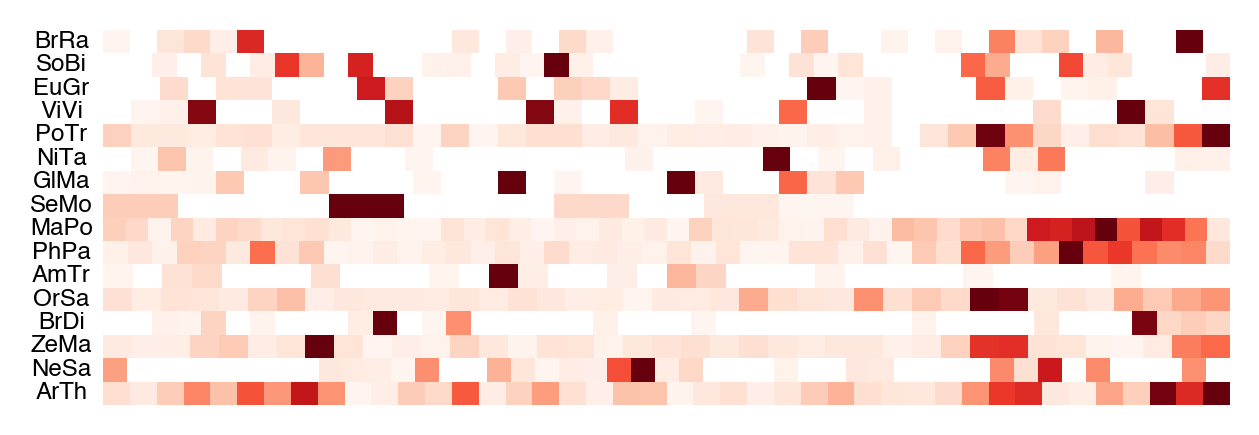

In [18]:
fig, axs = plt.subplots(len(orthologs["Description_name"].unique()), 1, figsize = (4, 1.25), dpi = 300)

i = 0
for descrip in orthologs["Description_name"].unique():
    plot_one_org_heatmap(descrip, axs[i])
    i += 1

plt.tight_layout(pad = 0)

# Try 2

In [19]:
orthologs

,Start,End,Description,Other,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end,name,tile_num,mid,Description_name,normalized_Activity_S3_1
471,1,41,BasicBrRa.1,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCH,4741.0,187.276143,NaN,1.0,NaN,NaN,B.rapa,1,21,BasicBrRa,0.031225
472,11,51,BasicBrRa.2,B.rapa_Brara.G00896.1.p_Macovei,NRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNSHEVD,NaN,NaN,NaN,NaN,NaN,NaN,B.rapa,2,31,BasicBrRa,NaN
473,21,61,BasicBrRa.3,B.rapa_Brara.G00896.1.p_Macovei,SDPCPTVWNTNPTRHCPNCHHVIDNSHEVDDWPGLPRGVK,6219.0,650.731599,NaN,1.0,NaN,NaN,B.rapa,3,41,BasicBrRa,0.108498
474,31,71,BasicBrRa.4,B.rapa_Brara.G00896.1.p_Macovei,NPTRHCPNCHHVIDNSHEVDDWPGLPRGVKFDPSDPEIIW,4954.0,902.494857,287.599290,4.0,614.895568,1190.094147,B.rapa,4,51,BasicBrRa,0.150475
475,41,81,BasicBrRa.5,B.rapa_Brara.G00896.1.p_Macovei,HVIDNSHEVDDWPGLPRGVKFDPSDPEIIWHLLAKTGSLG,3090.0,394.336560,NaN,1.0,NaN,NaN,B.rapa,5,61,BasicBrRa,0.065749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3012,371,411,BasicArTh.38,Q6NQK2,GSQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,2924.0,904.569692,1320.706714,6.0,-416.137023,2225.276406,Q6NQK2,38,391,BasicArTh,0.150821
3013,381,421,BasicArTh.39,Q6NQK2,SGSLKDKQPCIADYAHLGPEDFKRDLEECQKIVLDPSNIE,6270.0,666.698396,559.960759,9.0,106.737637,1226.659155,Q6NQK2,39,401,BasicArTh,0.111160
3014,391,431,BasicArTh.40,Q6NQK2,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDTPPEFRLS,3263.0,2050.634351,1244.030950,9.0,806.603401,3294.665302,Q6NQK2,40,411,BasicArTh,0.341908
3015,401,441,BasicArTh.41,Q6NQK2,DFKRDLEECQKIVLDPSNIELDTPPEFRLSQLEFGSQDSF,712.0,1552.582733,1032.710596,9.0,519.872136,2585.293329,Q6NQK2,41,421,BasicArTh,0.258866


In [20]:
orthologs.to_csv("../data/sog1_orthologs_tile_activities.csv")

In [21]:
min(orthologs["Activity_S3_1"].dropna())

146.0

In [22]:
np.percentile(orthologs["Activity_S3_1"].dropna(), 95)

4036.969231774867

<Axes: xlabel='Activity_S3_1', ylabel='Count'>

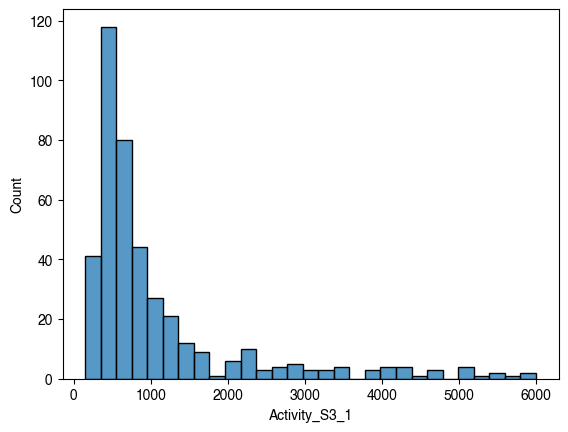

In [23]:
sns.histplot(orthologs["Activity_S3_1"])

<Axes: xlabel='norm_activity_2', ylabel='Count'>

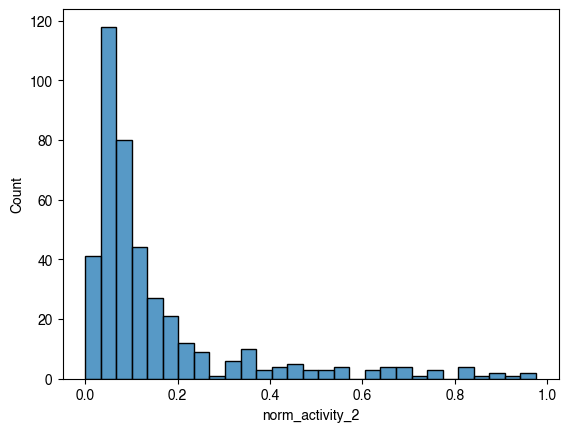

In [24]:
# Range from min to max, from 0 to 1
orthologs["norm_activity_2"] = (orthologs["Activity_S3_1"] - min(orthologs["Activity_S3_1"].dropna())) / np.percentile(orthologs["Activity_S3_1"].dropna(), 100)
sns.histplot(orthologs["norm_activity_2"])

In [25]:
sog1_orthologs

,Wild type sequences:,Unnamed: 1,name
0,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNS...,B.rapa
1,S.bicolor_Sobic.010G111800.2.p_Macovei,MPRRFFFFAVDGSSGQMMTFLYFGFNDKEDMSTVRMKTTWIIDSQR...,S.bicolor
2,E.grandis_Eucgr.G02349.1.p_Macovei,MAGPSWLVDSHRIATKIRSASGASDPEKVKWKSNPTRACPNCQHVI...,E.grandis
3,V.vinifera peptide_GSVIVT01011954001_Macovei,MSWLVDSNRFATKIKNASGTRETERVKWKSNPSRACPNCQHIIDNS...,V.vinifera peptide
4,PopulusTrichocarpaSOG1_Lib1,MAGPWLVDGNRFATKIKSASSASNHERVAWKSDPCKTCPNCHHVID...,PopulusTrichocarpa
5,Nicotianatabacum(tobacco)_A0A1S3X2K2_TAIR,MCYRFRRPSWLVDSKRIATKIKSASGDPGAVNWKSNPTKACPNCQF...,Nicotianatabacum(tobacco)
6,G.max_Glyma.10G204700.1.p_Macovei,MAGPSWLVDKSRIATKIKNVSGTCGKVIWKSNPSRACPSCHHVIDN...,G.max
7,Selaginellamoellendorffii(spikemoss)_D8RBR5_TAIR,MSQAPQDWTGLPAGVKFDPNDKEILDHLAAKIGRGGKPHALIDEFI...,Selaginellamoellendorffii(spikemoss)
8,MarchantiaPolymorphaSOG1_Lib1,MKNRDHRDRWGRFMDQLVRQIDNATHQRNDAYSLAQDDTTALPGLE...,MarchantiaPolymorpha
9,PhyscomitriumPatensSOG1_Lib1,MDRVASNRILGASKLRCDNNAAAHVKLDSFPAGVRFDPSDEELLEH...,PhyscomitriumPatens


In [26]:
sog1_orthologs["Unnamed: 1" ].str.rfind("SQ")

0     431
1     472
2     414
3     416
4     413
5     418
6     407
7       1
8     500
9     478
10    391
11    402
12    465
13    397
14    467
15    435
Name: Unnamed: 1, dtype: int64

In [27]:
def df_aligned_on_motif(motif_align, sog1_orthologs, orthologs, reverse = False):
    if reverse:
        sog1_orthologs["motif_pos"]=sog1_orthologs["Unnamed: 1" ].str.rfind(motif_align)
    else:
        sog1_orthologs["motif_pos"]=sog1_orthologs["Unnamed: 1" ].str.find(motif_align)
    sog1_orthologs["len"] = sog1_orthologs["Unnamed: 1"].str.len()
    sog1_orthologs = sog1_orthologs.sort_values(by = "len")

    orthologs_relative_pos = pd.merge(orthologs, sog1_orthologs[["name", "motif_pos", "len"]])
    orthologs_relative_pos["adj_mid"] = orthologs_relative_pos["mid"] - orthologs_relative_pos["motif_pos"]
    
    heatmap_df = orthologs_relative_pos[["Description_name", "norm_activity_2", "adj_mid"]]
    heatmap_df = heatmap_df.set_index('adj_mid')
    return orthologs_relative_pos, heatmap_df

In [28]:
# orthologs_relative_pos.to_csv("../data/sog1_orthologs_tile_activities.csv")

In [29]:
motif_align = "RWHKTG"
orthologs_relative_pos, heatmap_df = df_aligned_on_motif(motif_align, sog1_orthologs, orthologs)
heatmap_df

,Description_name,norm_activity_2
adj_mid,,
-125,BasicBrRa,0.006882
-115,BasicBrRa,NaN
-105,BasicBrRa,0.084155
-95,BasicBrRa,0.126132
-85,BasicBrRa,0.041406
...,...,...
242,BasicArTh,0.126478
252,BasicArTh,0.086817
262,BasicArTh,0.317565


In [30]:
orthologs_relative_pos.to_csv("../data/sog1_orthologs_tile_activities.csv")

In [31]:
max(heatmap_df.index)

348

In [32]:
min(heatmap_df.index)

-161

In [33]:
end_order = orthologs_relative_pos[["Description_name", "adj_mid"]].groupby("Description_name").max().sort_values(by = "adj_mid")
end_order = end_order.index

In [34]:
len_asc_order = orthologs_relative_pos[["Description_name", "len"]].drop_duplicates().sort_values(by = "len", ascending = True)["Description_name"]

In [35]:
heatmap_df[heatmap_df["Description_name"] == "BasicEuGr"][["norm_activity_2"]].index[0]

-128

In [36]:
from scipy.ndimage.filters import gaussian_filter

<Axes: xlabel='adj_mid'>

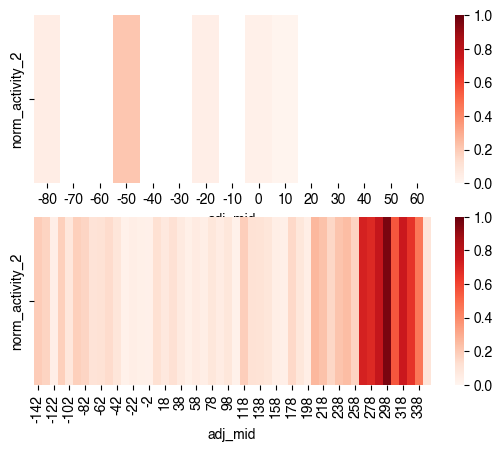

In [37]:
fig, axs = plt.subplots(2, 1)

df = heatmap_df[heatmap_df["Description_name"] == "BasicSeMo"]
df = df[["norm_activity_2"]].T

sns.heatmap(df, vmin = 0, vmax = 1, cmap = "Reds", ax = axs[0])
#axs[0].set_xlim(1, 10)

df = heatmap_df[heatmap_df["Description_name"] == "BasicMaPo"]
df = df[["norm_activity_2"]].T
sns.heatmap(df, vmin = 0, vmax = 1, cmap = "Reds", ax = axs[1])

<Axes: xlabel='adj_mid'>

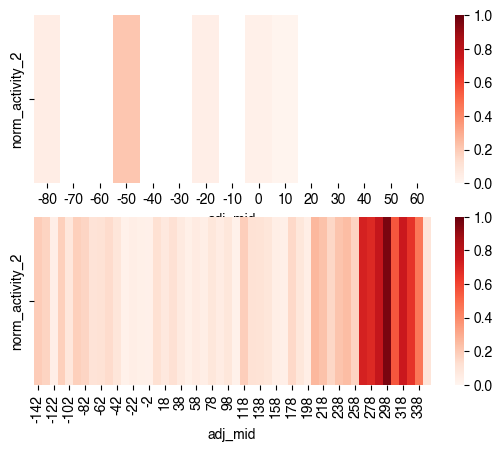

In [38]:
fig, axs = plt.subplots(2, 1, sharex= False)

df = heatmap_df[heatmap_df["Description_name"] == "BasicSeMo"]
df = df[["norm_activity_2"]].T

sns.heatmap(df, vmin = 0, vmax = 1, cmap = "Reds", ax = axs[0])


df = heatmap_df[heatmap_df["Description_name"] == "BasicMaPo"]
df = df[["norm_activity_2"]].T
sns.heatmap(df, vmin = 0, vmax = 1, cmap = "Reds", ax = axs[1])

In [39]:
df.T

,norm_activity_2
adj_mid,
-142,0.194938
-132,0.164180
-122,0.039926
-112,0.181511
-102,0.082988
-92,0.181171
-82,0.162259
-72,0.107161
-62,0.116645


In [40]:
df.T.interpolate()

,norm_activity_2
adj_mid,
-142,0.194938
-132,0.164180
-122,0.039926
-112,0.181511
-102,0.082988
-92,0.181171
-82,0.162259
-72,0.107161
-62,0.116645


<Axes: xlabel='adj_mid'>

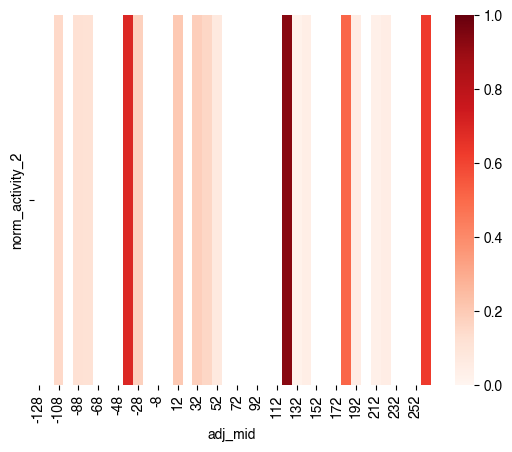

In [41]:
fig, ax = plt.subplots()
df = heatmap_df[heatmap_df["Description_name"] == "BasicEuGr"]
df = df[["norm_activity_2"]].T

sns.heatmap(df, vmin = 0, vmax = 1, cmap = "Reds", ax = ax)

In [42]:
mapping = orthologs[["Description_name", "name"]].drop_duplicates()
mapping["name"] = mapping["name"].str.split(" ").str[0]
mapping_dict = dict(zip(mapping["Description_name"], mapping["name"]))
mapping_dict["BasicArTh"] = "A.thaliana"
mapping_dict["BasicPoTr"] = "P.trichocarpa"
mapping_dict["BasicNiTa"] = "N.tabacum"
mapping_dict["BasicSeMo"] = "S.moellendorffii"
mapping_dict["BasicMaPo"] = "M.polymorpha"
mapping_dict["BasicPhPa"] = "P.patens"
mapping_dict["BasicAmTr"] = "A.trichopoda"
mapping_dict["BasicOrSa"] = "O.sativa"
mapping_dict["BasicZeMa"] = "Z.mays"
mapping_dict["BasicNeSa"] = "N.nucifera"
mapping_dict

{'BasicBrRa': 'B.rapa',
 'BasicSoBi': 'S.bicolor',
 'BasicEuGr': 'E.grandis',
 'BasicViVi': 'V.vinifera',
 'BasicPoTr': 'P.trichocarpa',
 'BasicNiTa': 'N.tabacum',
 'BasicGlMa': 'G.max',
 'BasicSeMo': 'S.moellendorffii',
 'BasicMaPo': 'M.polymorpha',
 'BasicPhPa': 'P.patens',
 'BasicAmTr': 'A.trichopoda',
 'BasicOrSa': 'O.sativa',
 'BasicBrDi': 'B.distachyon',
 'BasicZeMa': 'Z.mays',
 'BasicNeSa': 'N.nucifera',
 'BasicArTh': 'A.thaliana'}

In [43]:
heatmap_df

,Description_name,norm_activity_2
adj_mid,,
-125,BasicBrRa,0.006882
-115,BasicBrRa,NaN
-105,BasicBrRa,0.084155
-95,BasicBrRa,0.126132
-85,BasicBrRa,0.041406
...,...,...
242,BasicArTh,0.126478
252,BasicArTh,0.086817
262,BasicArTh,0.317565


In [44]:
mapping_dict

{'BasicBrRa': 'B.rapa',
 'BasicSoBi': 'S.bicolor',
 'BasicEuGr': 'E.grandis',
 'BasicViVi': 'V.vinifera',
 'BasicPoTr': 'P.trichocarpa',
 'BasicNiTa': 'N.tabacum',
 'BasicGlMa': 'G.max',
 'BasicSeMo': 'S.moellendorffii',
 'BasicMaPo': 'M.polymorpha',
 'BasicPhPa': 'P.patens',
 'BasicAmTr': 'A.trichopoda',
 'BasicOrSa': 'O.sativa',
 'BasicBrDi': 'B.distachyon',
 'BasicZeMa': 'Z.mays',
 'BasicNeSa': 'N.nucifera',
 'BasicArTh': 'A.thaliana'}

In [45]:
def plot_one_trace(descrip_name, ax, heatmap_df, last = False, plot_min = -161, plot_max = 348, interpolate = True):
    if descrip_name not in list(heatmap_df["Description_name"]):
        d_swap = {v: k for k, v in mapping_dict.items()}
        descrip_name = d_swap[descrip_name]

    x_min = heatmap_df[heatmap_df["Description_name"] == descrip_name][["norm_activity_2"]].index[0]
    x_max = heatmap_df[heatmap_df["Description_name"] == descrip_name][["norm_activity_2"]].index[-1]

    if interpolate:
        ax.imshow(heatmap_df[heatmap_df["Description_name"] == descrip_name][["norm_activity_2"]].interpolate(limit = 2).T,interpolation="gaussian", cmap = "rocket_r", vmin = 0, vmax = 0.95, extent = [x_min-5, x_max+5, 0, 20])
    else:
        ax.imshow(heatmap_df[heatmap_df["Description_name"] == descrip_name][["norm_activity_2"]].T,interpolation=None, cmap = "rocket_r", vmin = 0, vmax = 0.95, extent = [x_min-5, x_max+5, 0, 20])

    
    ax.set_xlim(plot_min, plot_max)
    ax.set_yticks([])    
    ax.set_xticks([])    
    sns.despine(bottom = True, left = True)
    ax.set_ylabel(mapping_dict[descrip_name], rotation = 0, fontsize = 'small', va = 'center', ha = 'right', labelpad = 5)
    #ax.axvline(0)

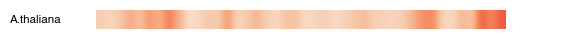

In [46]:
fig, ax = plt.subplots()
plot_one_trace("BasicArTh", ax, heatmap_df, last = False)

In [47]:
heatmap_df[heatmap_df["Description_name"] == "BasicSeMo"]

,Description_name,norm_activity_2
adj_mid,,
-80,BasicSeMo,0.049666
-70,BasicSeMo,NaN
-60,BasicSeMo,NaN
-50,BasicSeMo,0.212540
-40,BasicSeMo,NaN
-30,BasicSeMo,NaN
-20,BasicSeMo,0.041665
-10,BasicSeMo,NaN
0,BasicSeMo,0.028178


In [48]:
# fig, ax = plt.subplots()
# plot_one_trace("BasicEuGr", ax, last = True)

In [49]:
# fig, ax = plt.subplots()
# plot_one_trace("BasicSeMo", ax, last = True)
# ax.set_xticks([0])

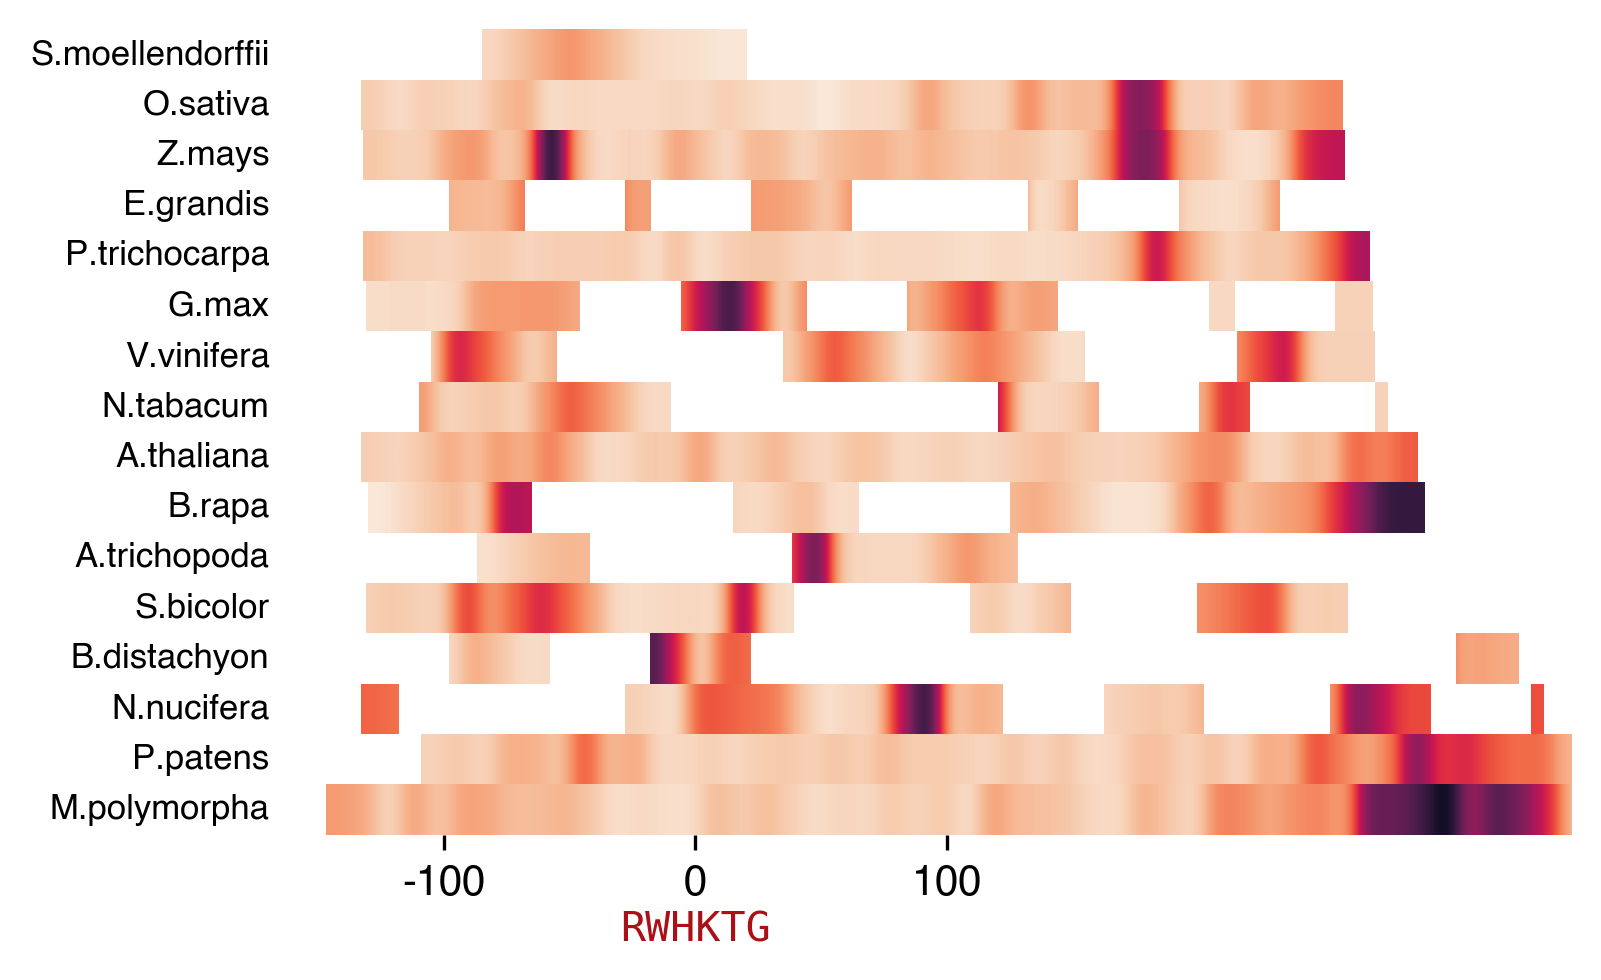

In [50]:
fig, axs = plt.subplots(len(sog1_orthologs["name"]), 1, figsize = (6,3), sharex = True, dpi = 300)

for name, ax in zip(end_order, axs):

    plot_one_trace(name, ax, heatmap_df)
    
    if name != "BasicMaPo":
        ax.set_xticks([])

axs[-1].set_xticks([-100, 0, 100])
axs[-1].set_xticklabels([-100, 0, 100])
        
axs[-1].text(x = 0, y = -30, va = "top", ha = "center", s = motif_align, color = sns.color_palette("Reds")[-1], font = 'monospace')

plt.tight_layout(pad = 0)

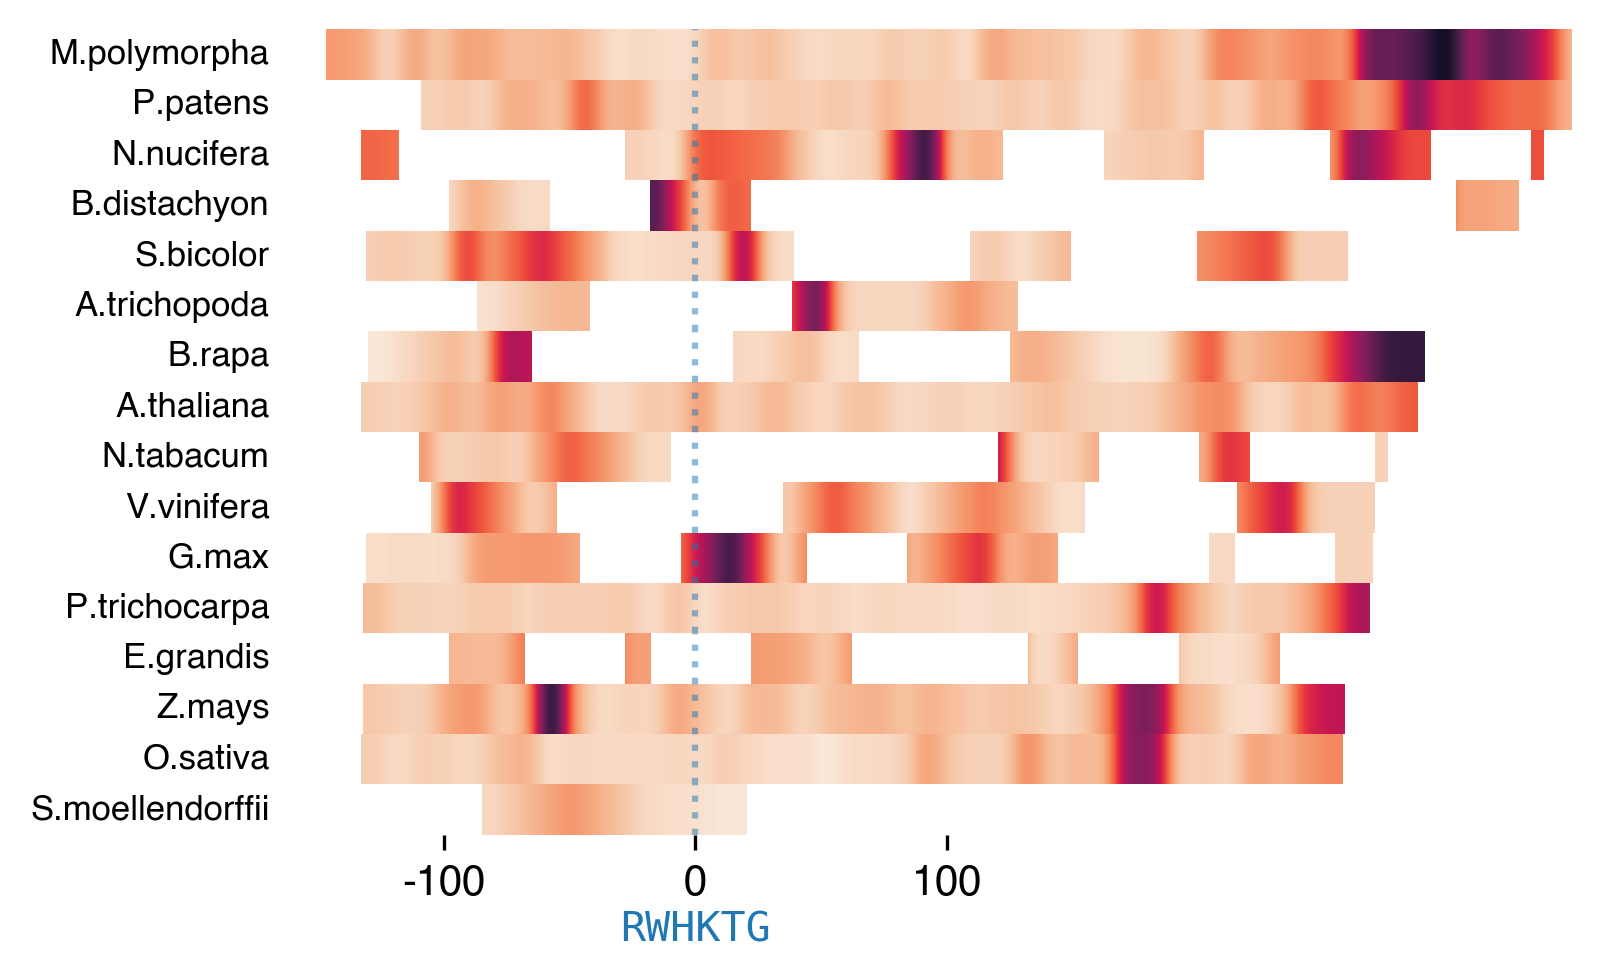

In [51]:
start_order = orthologs_relative_pos[["Description_name", "adj_mid"]].groupby("Description_name").max().sort_values(by = "adj_mid", ascending = False)
start_order = start_order.index

fig, axs = plt.subplots(len(sog1_orthologs["name"]), 1, figsize = (6,3), sharex = True, dpi = 300)

for name, ax in zip(start_order, axs):

    plot_one_trace(name, ax, heatmap_df)
    
    if name != "BasicMaPo":
        ax.set_xticks([])

    ax.axvline(0, alpha = 0.5, linestyle = 'dotted')

axs[-1].set_xticks([-100, 0, 100])
axs[-1].set_xticklabels([-100, 0, 100])
        
axs[-1].text(x = 0, y = -30, va = "top", ha = "center", s = motif_align, color = sns.color_palette("tab10")[0], font = 'monospace')

plt.tight_layout(pad = 0)
plt.savefig("../output/figures/orthologs_DBD.png")

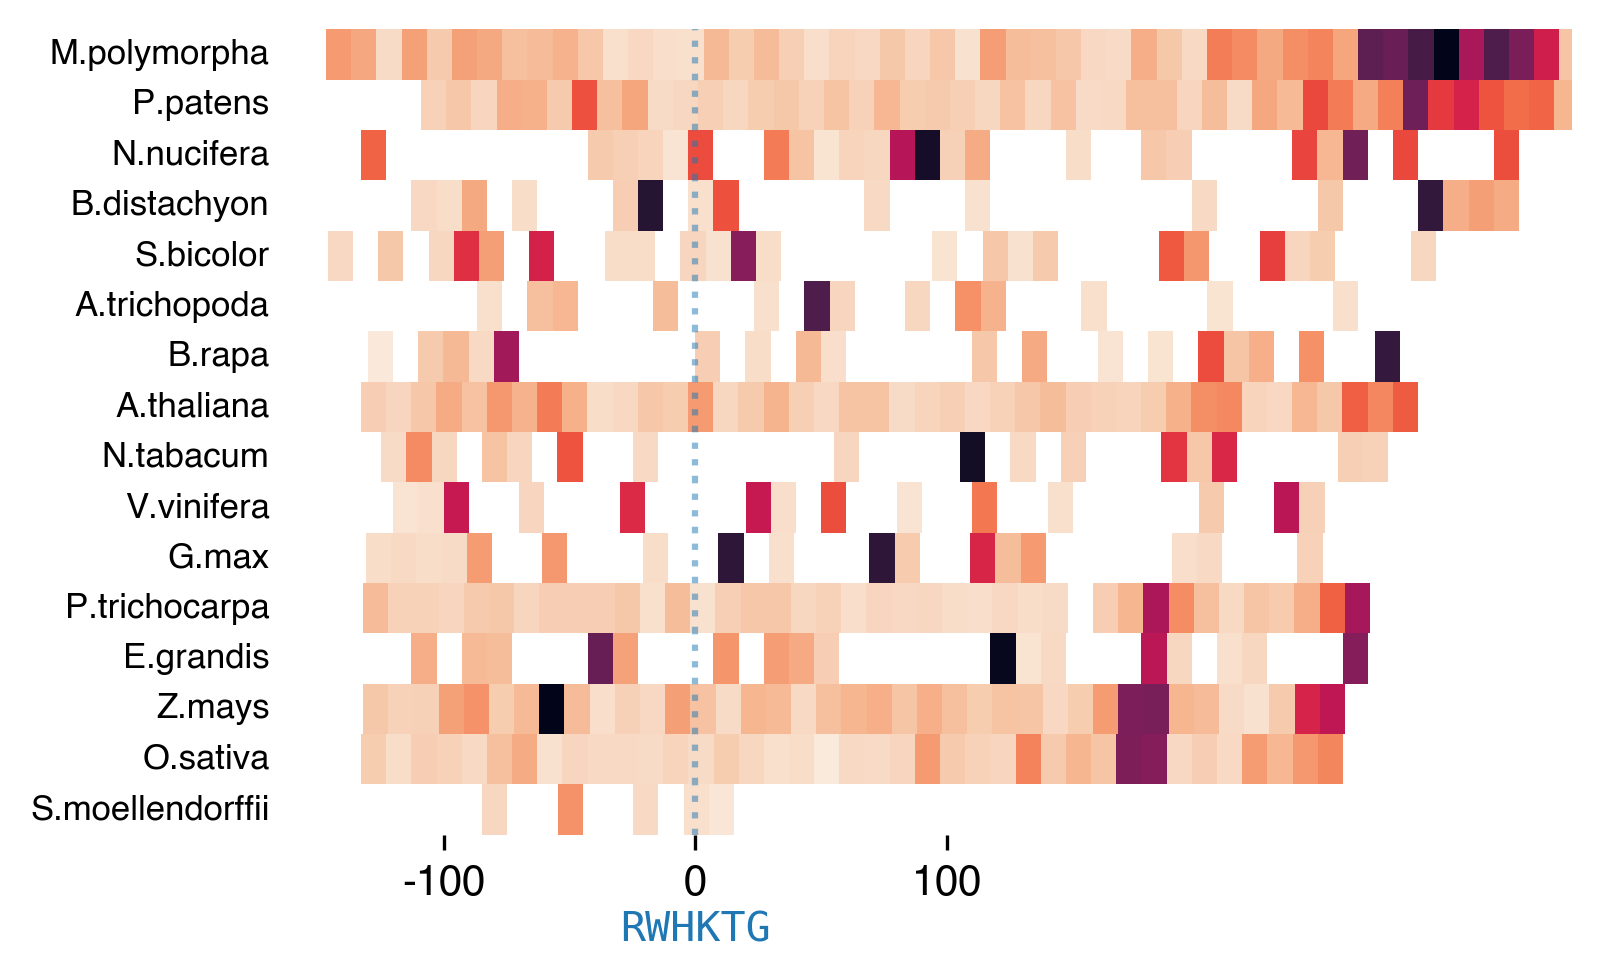

In [52]:
start_order = orthologs_relative_pos[["Description_name", "adj_mid"]].groupby("Description_name").max().sort_values(by = "adj_mid", ascending = False)
start_order = start_order.index

fig, axs = plt.subplots(len(sog1_orthologs["name"]), 1, figsize = (6,3), sharex = True, dpi = 300)

for name, ax in zip(start_order, axs):

    plot_one_trace(name, ax, heatmap_df, interpolate = None)
    
    if name != "BasicMaPo":
        ax.set_xticks([])

    ax.axvline(0, alpha = 0.5, linestyle = 'dotted')

axs[-1].set_xticks([-100, 0, 100])
axs[-1].set_xticklabels([-100, 0, 100])
        
axs[-1].text(x = 0, y = -30, va = "top", ha = "center", s = motif_align, color = sns.color_palette("tab10")[0], font = 'monospace')

plt.tight_layout(pad = 0)

In [53]:
orthologs_relative_pos[["Description_name", "End"]].groupby("Description_name").max().sort_values(by = "End", ascending = False)

,End
Description_name,
BasicMaPo,531
BasicNeSa,501
BasicBrDi,491
BasicPhPa,491
BasicSoBi,491
BasicArTh,451
BasicBrRa,451
BasicNiTa,441
BasicEuGr,431


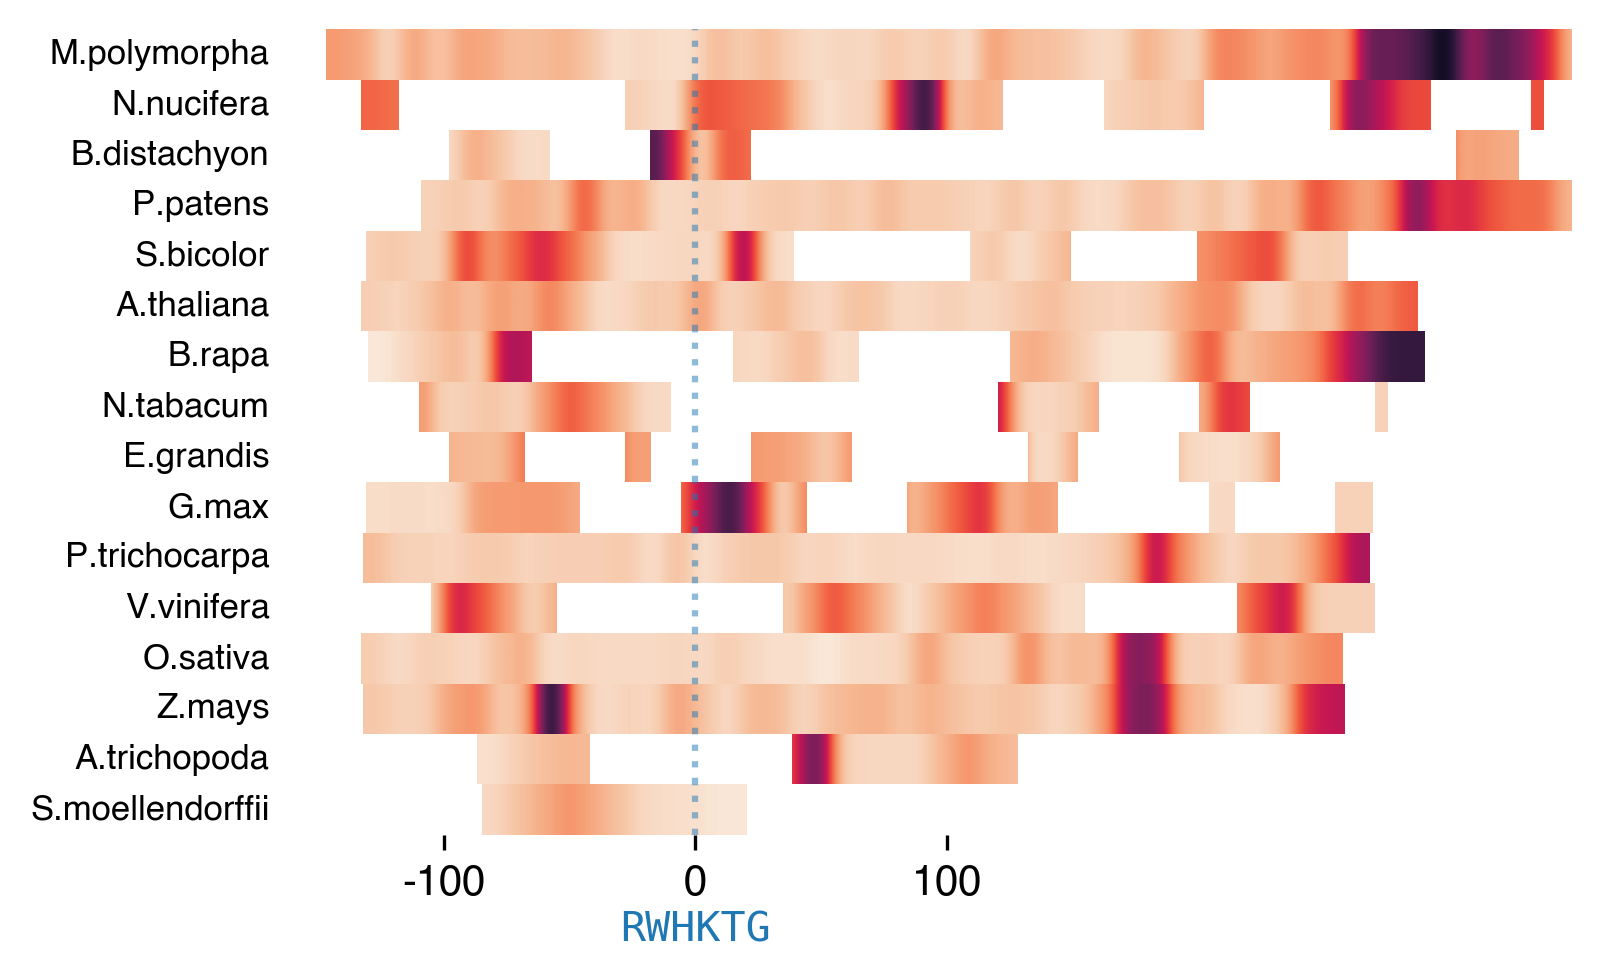

In [54]:
end_order = orthologs_relative_pos[["Description_name", "End"]].groupby("Description_name").max().sort_values(by = "End", ascending = False)
end_order = end_order.index

fig, axs = plt.subplots(len(sog1_orthologs["name"]), 1, figsize = (6,3), sharex = True, dpi = 300)

for name, ax in zip(end_order, axs):

    plot_one_trace(name, ax, heatmap_df)
    
    if name != "BasicMaPo":
        ax.set_xticks([])

    ax.axvline(0, alpha = 0.5, linestyle = 'dotted')

axs[-1].set_xticks([-100, 0, 100])
axs[-1].set_xticklabels([-100, 0, 100])
        
axs[-1].text(x = 0, y = -30, va = "top", ha = "center", s = motif_align, color = sns.color_palette("tab10")[0], font = 'monospace')

plt.tight_layout(pad = 0)
#plt.savefig("../output/figures/orthologs_DBD.png")

In [55]:
orthologs_relative_pos

,Start,End,Description,Other,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end,name,tile_num,mid,Description_name,normalized_Activity_S3_1,norm_activity_2,motif_pos,len,adj_mid
0,1,41,BasicBrRa.1,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCH,4741.0,187.276143,NaN,1.0,NaN,NaN,B.rapa,1,21,BasicBrRa,0.031225,0.006882,146,445,-125
1,11,51,BasicBrRa.2,B.rapa_Brara.G00896.1.p_Macovei,NRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNSHEVD,NaN,NaN,NaN,NaN,NaN,NaN,B.rapa,2,31,BasicBrRa,NaN,NaN,146,445,-115
2,21,61,BasicBrRa.3,B.rapa_Brara.G00896.1.p_Macovei,SDPCPTVWNTNPTRHCPNCHHVIDNSHEVDDWPGLPRGVK,6219.0,650.731599,NaN,1.0,NaN,NaN,B.rapa,3,41,BasicBrRa,0.108498,0.084155,146,445,-105
3,31,71,BasicBrRa.4,B.rapa_Brara.G00896.1.p_Macovei,NPTRHCPNCHHVIDNSHEVDDWPGLPRGVKFDPSDPEIIW,4954.0,902.494857,287.599290,4.0,614.895568,1190.094147,B.rapa,4,51,BasicBrRa,0.150475,0.126132,146,445,-95
4,41,81,BasicBrRa.5,B.rapa_Brara.G00896.1.p_Macovei,HVIDNSHEVDDWPGLPRGVKFDPSDPEIIWHLLAKTGSLG,3090.0,394.336560,NaN,1.0,NaN,NaN,B.rapa,5,61,BasicBrRa,0.065749,0.041406,146,445,-85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646,371,411,BasicArTh.38,Q6NQK2,GSQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,2924.0,904.569692,1320.706714,6.0,-416.137023,2225.276406,Q6NQK2,38,391,BasicArTh,0.150821,0.126478,149,449,242
647,381,421,BasicArTh.39,Q6NQK2,SGSLKDKQPCIADYAHLGPEDFKRDLEECQKIVLDPSNIE,6270.0,666.698396,559.960759,9.0,106.737637,1226.659155,Q6NQK2,39,401,BasicArTh,0.111160,0.086817,149,449,252
648,391,431,BasicArTh.40,Q6NQK2,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDTPPEFRLS,3263.0,2050.634351,1244.030950,9.0,806.603401,3294.665302,Q6NQK2,40,411,BasicArTh,0.341908,0.317565,149,449,262
649,401,441,BasicArTh.41,Q6NQK2,DFKRDLEECQKIVLDPSNIELDTPPEFRLSQLEFGSQDSF,712.0,1552.582733,1032.710596,9.0,519.872136,2585.293329,Q6NQK2,41,421,BasicArTh,0.258866,0.234523,149,449,272


# Tree

In [56]:
sog1_orthologs_w_name = pd.merge(sog1_orthologs, orthologs[["name", "Description_name"]].drop_duplicates(), on = "name", how = "left")
sog1_orthologs_w_name["standard_name"] = sog1_orthologs_w_name["Description_name"].map(mapping_dict)
sog1_orthologs_w_name

,Wild type sequences:,Unnamed: 1,name,motif_pos,len,Description_name,standard_name
0,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNS...,B.rapa,146,445,BasicBrRa,B.rapa
1,S.bicolor_Sobic.010G111800.2.p_Macovei,MPRRFFFFAVDGSSGQMMTFLYFGFNDKEDMSTVRMKTTWIIDSQR...,S.bicolor,182,488,BasicSoBi,S.bicolor
2,E.grandis_Eucgr.G02349.1.p_Macovei,MAGPSWLVDSHRIATKIRSASGASDPEKVKWKSNPTRACPNCQHVI...,E.grandis,149,429,BasicEuGr,E.grandis
3,V.vinifera peptide_GSVIVT01011954001_Macovei,MSWLVDSNRFATKIKNASGTRETERVKWKSNPSRACPNCQHIIDNS...,V.vinifera peptide,146,430,BasicViVi,V.vinifera
4,PopulusTrichocarpaSOG1_Lib1,MAGPWLVDGNRFATKIKSASSASNHERVAWKSDPCKTCPNCHHVID...,PopulusTrichocarpa,148,428,BasicPoTr,P.trichocarpa
5,Nicotianatabacum(tobacco)_A0A1S3X2K2_TAIR,MCYRFRRPSWLVDSKRIATKIKSASGDPGAVNWKSNPTKACPNCQF...,Nicotianatabacum(tobacco),151,440,BasicNiTa,N.tabacum
6,G.max_Glyma.10G204700.1.p_Macovei,MAGPSWLVDKSRIATKIKNVSGTCGKVIWKSNPSRACPSCHHVIDN...,G.max,147,422,BasicGlMa,G.max
7,Selaginellamoellendorffii(spikemoss)_D8RBR5_TAIR,MSQAPQDWTGLPAGVKFDPNDKEILDHLAAKIGRGGKPHALIDEFI...,Selaginellamoellendorffii(spikemoss),101,172,BasicSeMo,S.moellendorffii
8,MarchantiaPolymorphaSOG1_Lib1,MKNRDHRDRWGRFMDQLVRQIDNATHQRNDAYSLAQDDTTALPGLE...,MarchantiaPolymorpha,163,523,BasicMaPo,M.polymorpha
9,PhyscomitriumPatensSOG1_Lib1,MDRVASNRILGASKLRCDNNAAAHVKLDSFPAGVRFDPSDEELLEH...,PhyscomitriumPatens,125,483,BasicPhPa,P.patens


In [57]:
protfasta.write_fasta(dict(zip(sog1_orthologs_w_name["standard_name"], sog1_orthologs_w_name["Unnamed: 1"])), "../data/sog1_orthologs.fasta")

In [58]:
! mafft --auto --quiet ../data/sog1_orthologs.fasta > ../data/sog1_orthologs_aligned.fasta

In [59]:
# !  FastTree sog1_orthologs_aligned.fasta > sog1_orthologs_tree

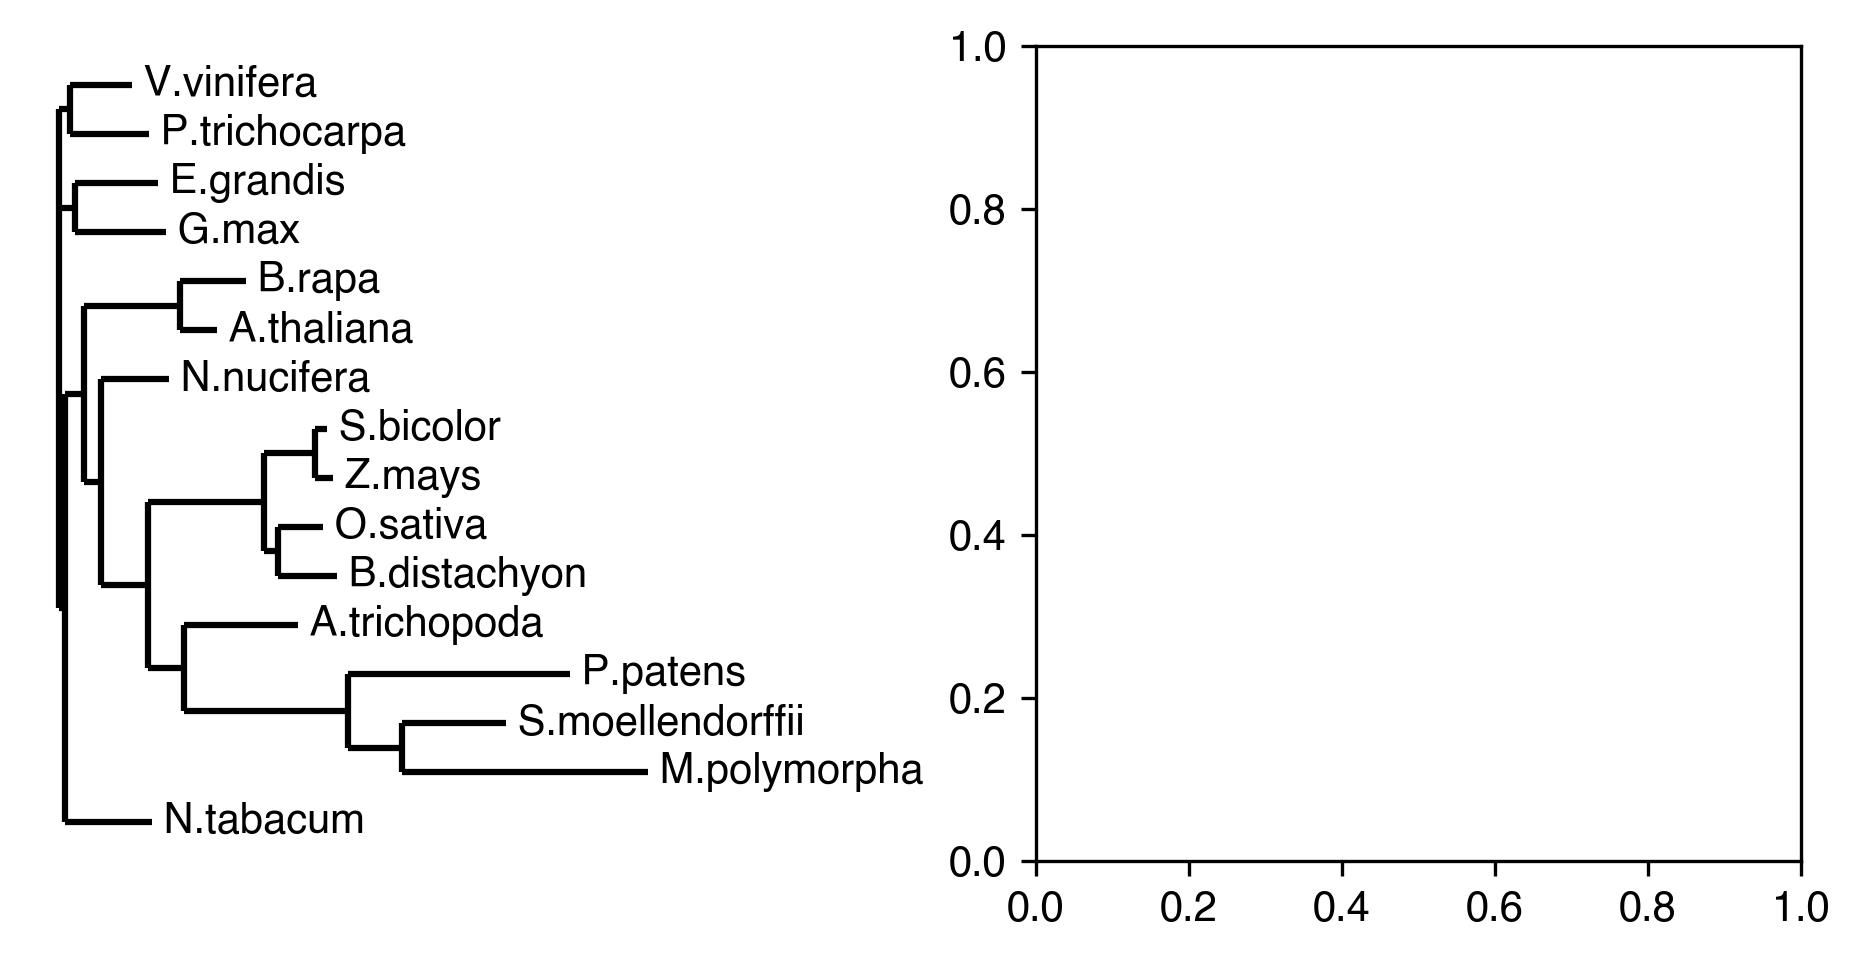

In [60]:
import matplotlib.pyplot as plt
from Bio import Phylo
import seaborn as sns

# Example: Read the first Newick formatted tree
tree1 = Phylo.read("../data/sog1_orthologs_tree", "newick")
#tree2 = Phylo.read("../data/another_tree.tree", "newick")  # Replace with your second tree file

# Create a figure with subplots (2 subplots side by side)
fig, axs = plt.subplots(1, 2, figsize=(6, 3), dpi = 300)

# Draw the first tree in the first subplot
Phylo.draw(tree1, do_show=False, axes=axs[0], show_confidence=False)  # Pass axes to the draw function
sns.despine(ax=axs[0], left = True, bottom = True)  # Remove the top and right spines
axs[0].set_xticks([])
axs[0].set_yticks([])
#axs[0].set_title("Tree 1")  # Set title for the first tree
axs[0].set_xlabel("")
axs[0].set_ylabel("")

# # Draw the second tree in the second subplot
# Phylo.draw(tree2, do_show=False, axes=axs[1])  # Pass axes to the draw function
# sns.despine(ax=axs[1])  # Remove the top and right spines
# axs[1].set_title("Tree 2")  # Set title for the second tree

# Adjust layout for better spacing
plt.tight_layout(pad = 0)

# Show the plots
plt.show()


In [61]:
tree1 = Phylo.read("../data/sog1_orthologs_tree", "newick")

name_order = []
for entry in tree1.get_terminals():
   name_order.append(entry.name)

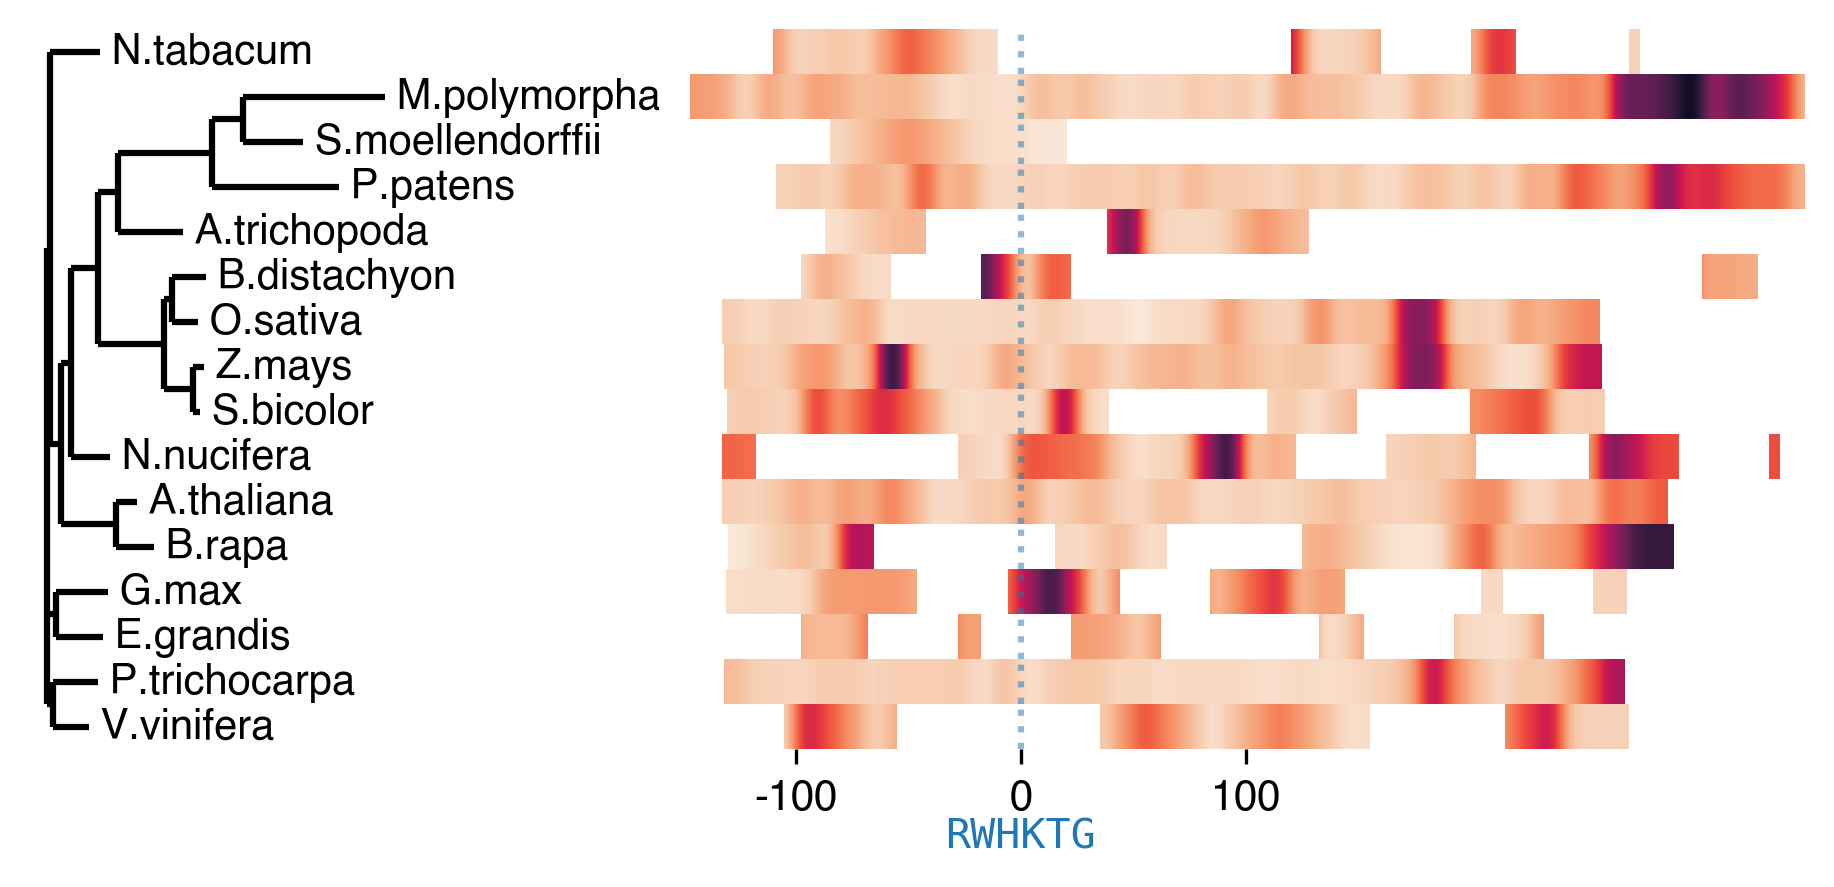

In [62]:
def annotate_axes(ax, text, fontsize=18):
    ax.text(0.5, 0.5, text, transform=ax.transAxes,
            ha="center", va="center", fontsize=fontsize, color="darkgrey")
    
fig = plt.figure(figsize=(6,2.7
                         ), dpi = 300)
spec = fig.add_gridspec(16,2, width_ratios = [1.1, 3])

ax0 = fig.add_subplot(spec[:, 0])

# Draw tree
# Draw the first tree in the first subplot
Phylo.draw(tree1, do_show=False, axes=ax0, show_confidence=False)  # Pass axes to the draw function
sns.despine(ax=ax0, left = True, bottom = True)  # Remove the top and right spines
ax0.set_xticks([])
ax0.set_yticks([])
#axs[0].set_title("Tree 1")  # Set title for the first tree
ax0.set_xlabel("")
ax0.set_ylabel("")
ax0.set_ylim(0.5,16.5)

for i in range(len(name_order)):
    ax_i = fig.add_subplot(spec[i, 1])
    plot_one_trace(name_order[len(name_order) - i - 1], ax_i, heatmap_df)
    
    if name != "BasicMaPo":
        ax_i.set_xticks([])

    ax_i.axvline(0, alpha = 0.5, linestyle = 'dotted')
    ax_i.set_ylabel("")

ax_i.set_xticks([-100, 0, 100])
ax_i.set_xticklabels([-100, 0, 100])
        
ax_i.text(x = 0, y = -30, va = "top", ha = "center", s = motif_align, color = sns.color_palette("tab10")[0], font = 'monospace')


# ax10 = fig.add_subplot(spec[0, 1])
# annotate_axes(ax10, 'ax10')

# ax10 = fig.add_subplot(spec[1, 1])
# annotate_axes(ax10, 'ax10')

# ax11 = fig.add_subplot(spec[1, 1])
# annotate_axes(ax11, 'ax11')

plt.tight_layout(pad = 0)

#fig.suptitle('Manually added subplots, spanning a column')

## 

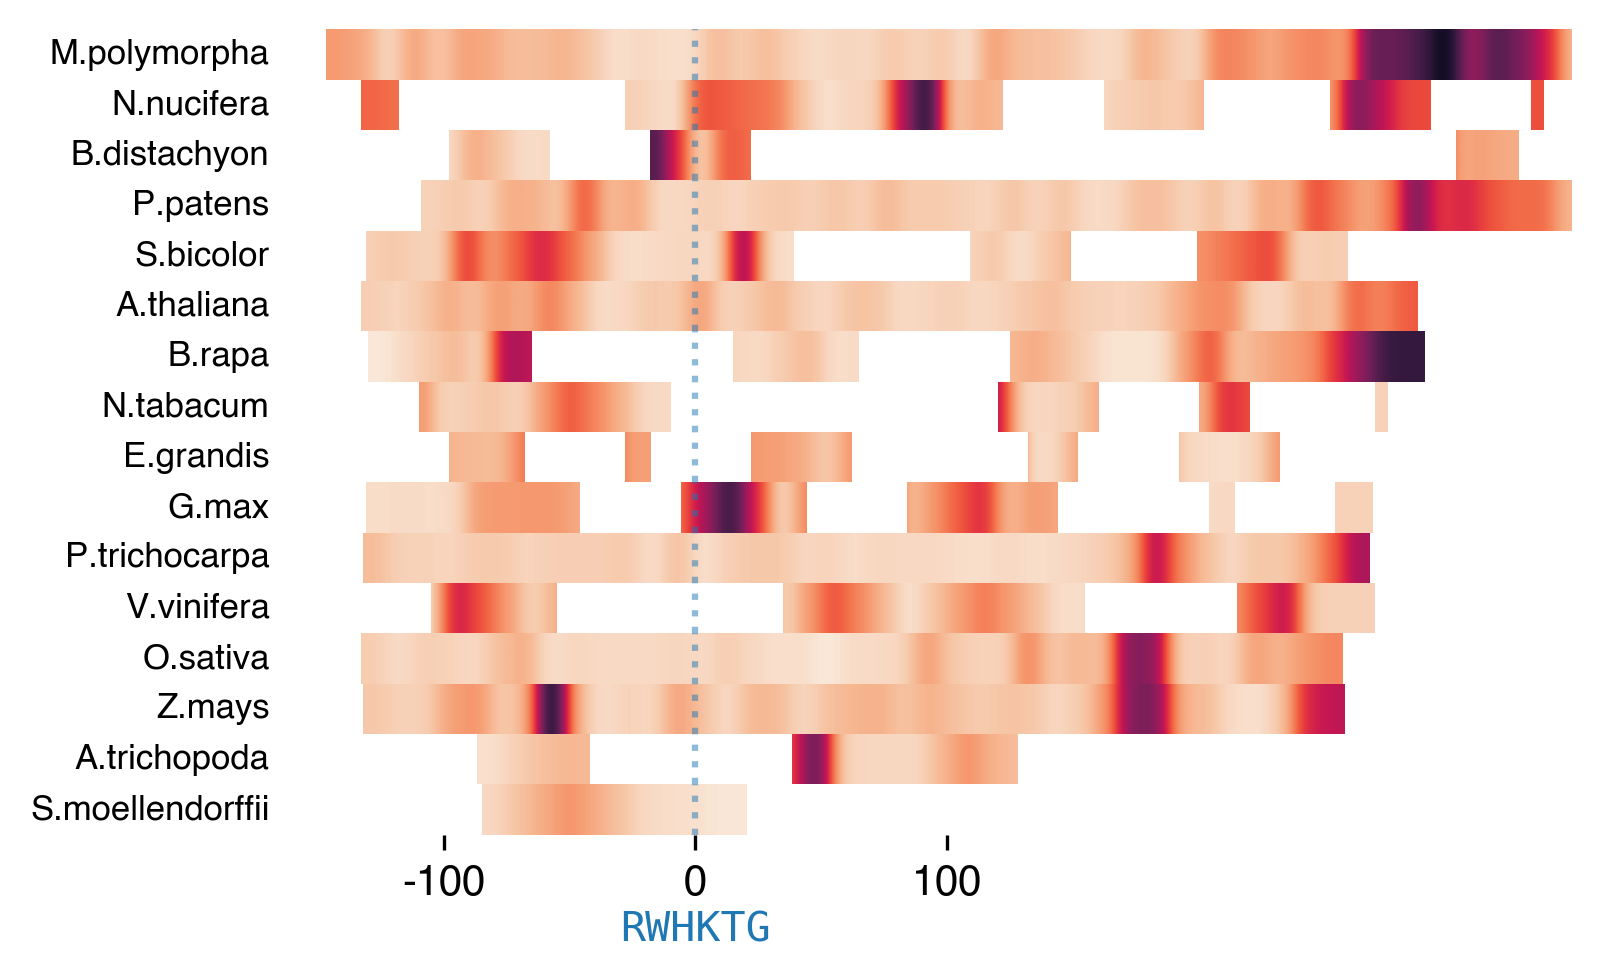

In [63]:
end_order = orthologs_relative_pos[["Description_name", "End"]].groupby("Description_name").max().sort_values(by = "End", ascending = False)
end_order = end_order.index

fig, axs = plt.subplots(len(sog1_orthologs["name"]), 1, figsize = (6,3), sharex = True, dpi = 300)

for name, ax in zip(end_order, axs):

    plot_one_trace(name, ax, heatmap_df)
    
    if name != "BasicMaPo":
        ax.set_xticks([])

    ax.axvline(0, alpha = 0.5, linestyle = 'dotted')

axs[-1].set_xticks([-100, 0, 100])
axs[-1].set_xticklabels([-100, 0, 100])
        
axs[-1].text(x = 0, y = -30, va = "top", ha = "center", s = motif_align, color = sns.color_palette("tab10")[0], font = 'monospace')

plt.tight_layout(pad = 0)
#plt.savefig("../output/figures/orthologs_DBD.png")

# [IGNORE] Align on last SQE or SQD

In [69]:
motif_align = "SQ"
orthologs_relative_pos, heatmap_df = df_aligned_on_motif(motif_align, sog1_orthologs, orthologs, reverse=True)
orthologs_relative_pos

,Start,End,Description,Other,tile,Activity_S3_1,Activity_S3_2,lib2_avg,name,tile_num,mid,Description_name,normalized_Activity_S3_1,norm_activity_2,motif_pos,len,adj_mid
0,1,41,BasicBrRa.1,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCH,372.197467,436.667606,404.432536,B.rapa,1,21,BasicBrRa,0.064630,0.028909,431,445,-410
1,11,51,BasicBrRa.2,B.rapa_Brara.G00896.1.p_Macovei,NRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNSHEVD,NaN,NaN,NaN,B.rapa,2,31,BasicBrRa,NaN,NaN,431,445,-400
2,21,61,BasicBrRa.3,B.rapa_Brara.G00896.1.p_Macovei,SDPCPTVWNTNPTRHCPNCHHVIDNSHEVDDWPGLPRGVK,765.501115,715.751065,740.626090,B.rapa,3,41,BasicBrRa,0.132925,0.097204,431,445,-390
3,31,71,BasicBrRa.4,B.rapa_Brara.G00896.1.p_Macovei,NPTRHCPNCHHVIDNSHEVDDWPGLPRGVKFDPSDPEIIW,947.655601,961.930688,954.793145,B.rapa,4,51,BasicBrRa,0.164555,0.128834,431,445,-380
4,41,81,BasicBrRa.5,B.rapa_Brara.G00896.1.p_Macovei,HVIDNSHEVDDWPGLPRGVKFDPSDPEIIWHLLAKTGSLG,540.798443,423.104489,481.951466,B.rapa,5,61,BasicBrRa,0.093907,0.058186,431,445,-370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646,371,411,BasicArTh.38,Q6NQK2,GSQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,601.553077,3400.972046,2001.262561,Q6NQK2,38,391,BasicArTh,0.104457,0.068735,435,449,-44
647,381,421,BasicArTh.39,Q6NQK2,SGSLKDKQPCIADYAHLGPEDFKRDLEECQKIVLDPSNIE,508.338058,1512.228706,1010.283382,Q6NQK2,39,401,BasicArTh,0.088270,0.052549,435,449,-34
648,391,431,BasicArTh.40,Q6NQK2,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDTPPEFRLS,1960.462356,1783.792784,1872.127570,Q6NQK2,40,411,BasicArTh,0.340424,0.304703,435,449,-24
649,401,441,BasicArTh.41,Q6NQK2,DFKRDLEECQKIVLDPSNIELDTPPEFRLSQLEFGSQDSF,2216.350444,2335.951103,2276.150773,Q6NQK2,41,421,BasicArTh,0.384858,0.349137,435,449,-14


In [70]:
orthologs_relative_pos[orthologs_relative_pos["Description_name"] == "BasicPhPa"]

,Start,End,Description,Other,tile,Activity_S3_1,Activity_S3_2,lib2_avg,name,tile_num,mid,Description_name,normalized_Activity_S3_1,norm_activity_2,motif_pos,len,adj_mid
354,1,41,BasicPhPa.1,PhyscomitriumPatens_PpSOG1a,MDRVASNRILGASKLRCDNNAAAHVKLDSFPAGVRFDPSD,580.941812,4003.164263,2292.053038,PhyscomitriumPatens,1,21,BasicPhPa,0.100877,0.065156,478,483,-457
355,11,51,BasicPhPa.2,PhyscomitriumPatens_PpSOG1a,GASKLRCDNNAAAHVKLDSFPAGVRFDPSDEELLEHLAAK,551.331077,919.873169,735.602123,PhyscomitriumPatens,2,31,BasicPhPa,0.095736,0.060015,478,483,-447
356,21,61,BasicPhPa.3,PhyscomitriumPatens_PpSOG1a,AAAHVKLDSFPAGVRFDPSDEELLEHLAAKIGRSSRKPHP,600.567519,NaN,600.567519,PhyscomitriumPatens,3,41,BasicPhPa,0.104285,0.068564,478,483,-437
357,31,71,BasicPhPa.4,PhyscomitriumPatens_PpSOG1a,PAGVRFDPSDEELLEHLAAKIGRSSRKPHPFLDEFIHTLV,965.666750,NaN,965.666750,PhyscomitriumPatens,4,51,BasicPhPa,0.167683,0.131962,478,483,-427
358,41,81,BasicPhPa.5,PhyscomitriumPatens_PpSOG1a,EELLEHLAAKIGRSSRKPHPFLDEFIHTLVEEDGICRTHP,662.372165,4035.944799,2349.158482,PhyscomitriumPatens,5,61,BasicPhPa,0.115017,0.079296,478,483,-417
359,51,91,BasicPhPa.6,PhyscomitriumPatens_PpSOG1a,IGRSSRKPHPFLDEFIHTLVEEDGICRTHPENLPGVKKDG,509.541059,1385.876521,947.708790,PhyscomitriumPatens,6,71,BasicPhPa,0.088479,0.052758,478,483,-407
360,61,101,BasicPhPa.7,PhyscomitriumPatens_PpSOG1a,FLDEFIHTLVEEDGICRTHPENLPGVKKDGSSCHYFHRPS,2731.730856,550.967106,1641.348981,PhyscomitriumPatens,7,81,BasicPhPa,0.474351,0.438630,478,483,-397
361,71,111,BasicPhPa.8,PhyscomitriumPatens_PpSOG1a,EEDGICRTHPENLPGVKKDGSSCHYFHRPSMAYTTGTRKR,322.380469,348.549646,335.465058,PhyscomitriumPatens,8,91,BasicPhPa,0.055980,0.020259,478,483,-387
362,81,121,BasicPhPa.9,PhyscomitriumPatens_PpSOG1a,ENLPGVKKDGSSCHYFHRPSMAYTTGTRKRRKIQTDDVPD,578.602518,1037.702447,808.152482,PhyscomitriumPatens,9,101,BasicPhPa,0.100471,0.064750,478,483,-377
363,91,131,BasicPhPa.10,PhyscomitriumPatens_PpSOG1a,SSCHYFHRPSMAYTTGTRKRRKIQTDDVPDGGTDVRWHKT,507.303290,791.970449,649.636869,PhyscomitriumPatens,10,111,BasicPhPa,0.088091,0.052369,478,483,-367


In [71]:
min(heatmap_df.index)

-479

In [72]:
max(heatmap_df.index)

160

In [73]:
heatmap_df.reset_index().groupby("Description_name").max().sort_values(by = "adj_mid").index

Index(['BasicPhPa', 'BasicViVi', 'BasicArTh', 'BasicEuGr', 'BasicPoTr',
       'BasicOrSa', 'BasicSoBi', 'BasicAmTr', 'BasicBrRa', 'BasicNiTa',
       'BasicGlMa', 'BasicZeMa', 'BasicBrDi', 'BasicMaPo', 'BasicNeSa',
       'BasicSeMo'],
      dtype='object', name='Description_name')

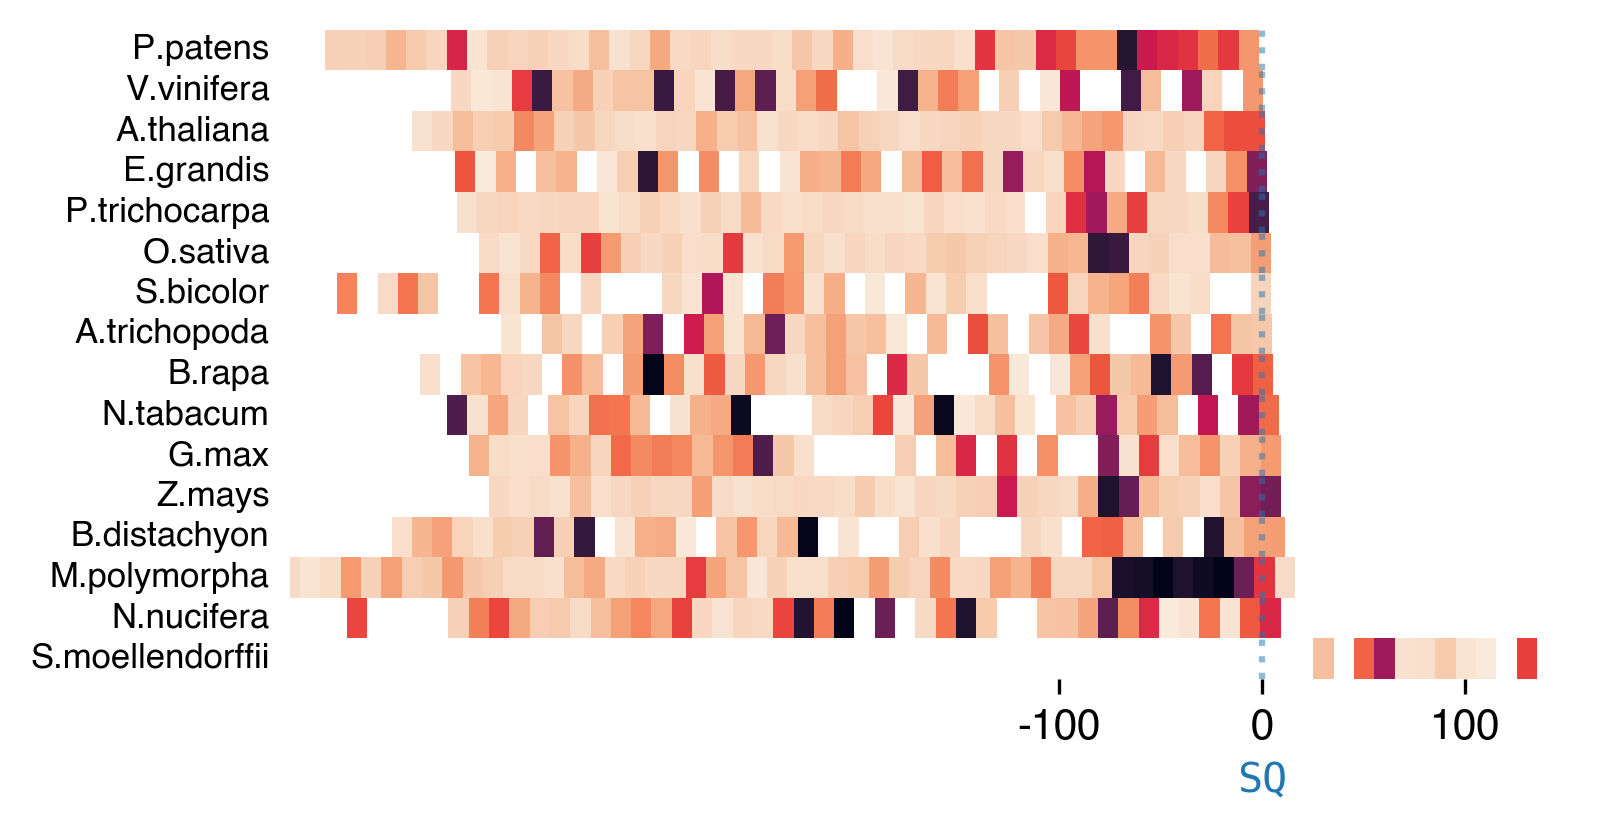

In [74]:
fig, axs = plt.subplots(len(sog1_orthologs["name"]), 1, figsize = (10,2.5), sharex = True, dpi = 300)


end_order = heatmap_df.reset_index().groupby("Description_name").max().sort_values(by = "adj_mid").index

for name, ax in zip(end_order, axs):
    plot_one_trace(name, ax, heatmap_df, plot_min = -479, plot_max = 160, interpolate = False)
    ax.axvline(0, alpha = 0.5, linestyle = 'dotted')

#plot_one_trace(name, ax, last)
    

    if name != "BasicMaPo":
        ax.set_xticks([])

axs[-1].set_xticks([-100, 0, 100])
axs[-1].set_xticklabels([-100, 0, 100])
        
axs[-1].text(x = 0, y = -40, va = "top", ha = "center", s = motif_align, color = sns.color_palette("tab10")[0], font = 'monospace')

plt.tight_layout(pad = 0)

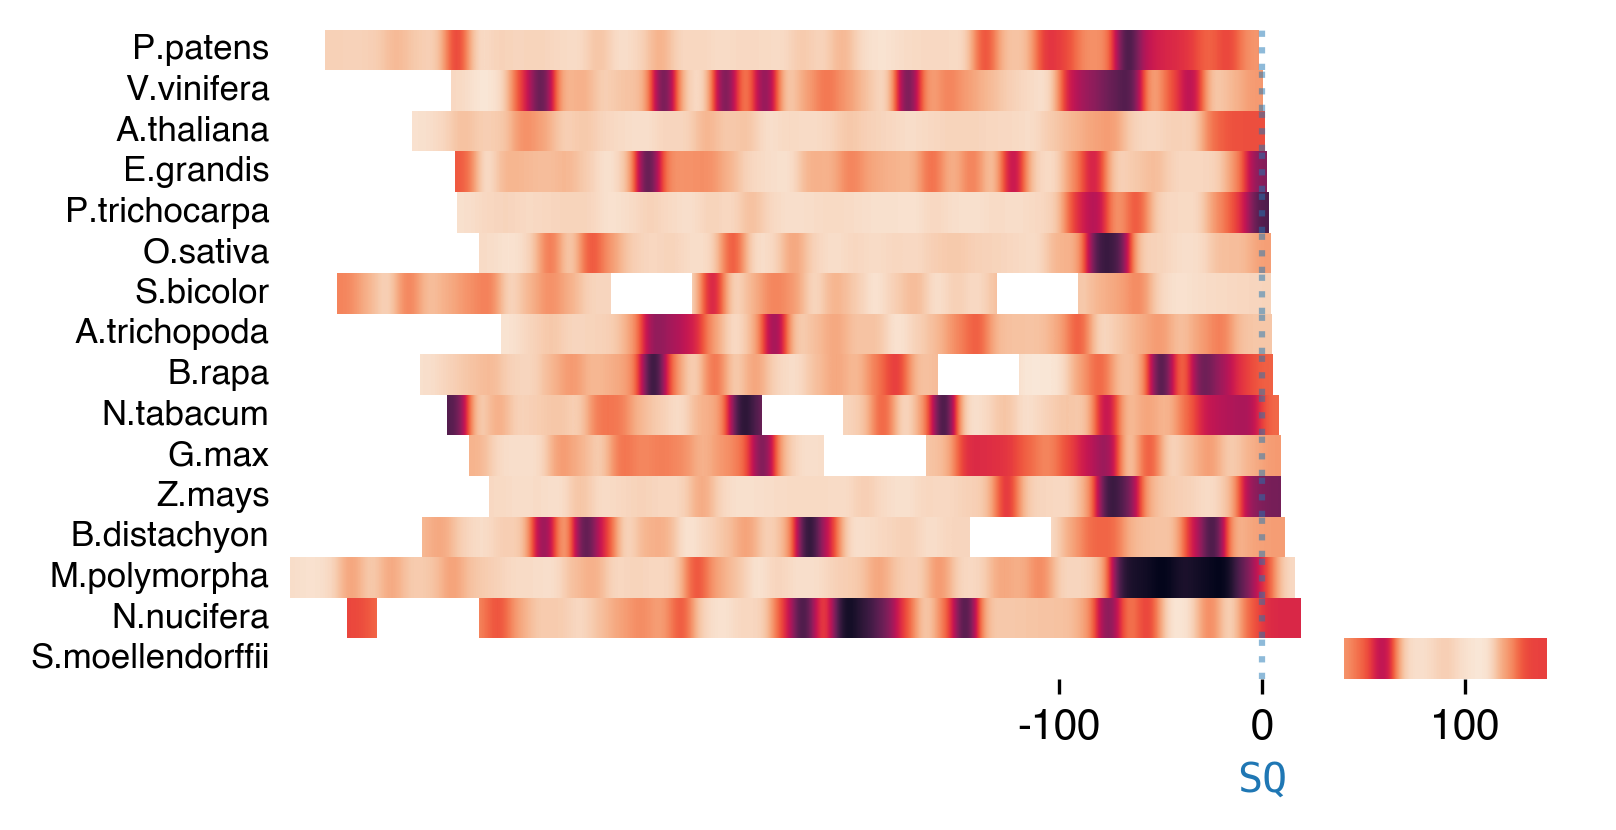

In [75]:
fig, axs = plt.subplots(len(sog1_orthologs["name"]), 1, figsize = (10,2.5), sharex = True, dpi = 300)


end_order = heatmap_df.reset_index().groupby("Description_name").max().sort_values(by = "adj_mid").index

for name, ax in zip(end_order, axs):
    plot_one_trace(name, ax, heatmap_df, plot_min = -479, plot_max = 160)
    ax.axvline(0, alpha = 0.5, linestyle = 'dotted')

#plot_one_trace(name, ax, last)
    

    if name != "BasicMaPo":
        ax.set_xticks([])

axs[-1].set_xticks([-100, 0, 100])
axs[-1].set_xticklabels([-100, 0, 100])
        
axs[-1].text(x = 0, y = -40, va = "top", ha = "center", s = motif_align, color = sns.color_palette("tab10")[0], font = 'monospace')

plt.tight_layout(pad = 0)

In [76]:
heatmap_df[heatmap_df["Description_name"] == "BasicSeMo"]

,Description_name,norm_activity_2
adj_mid,,
20,BasicSeMo,NaN
30,BasicSeMo,0.107467
40,BasicSeMo,NaN
50,BasicSeMo,0.309924
60,BasicSeMo,0.574911
70,BasicSeMo,0.025809
80,BasicSeMo,0.029577
90,BasicSeMo,0.081114
100,BasicSeMo,0.021083


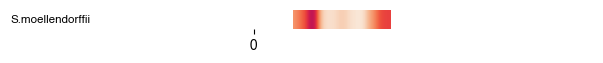

In [77]:
fig, ax = plt.subplots()
#plot_one_trace("BasicSeMo", ax, last = True, )

plot_one_trace("BasicSeMo", ax, heatmap_df)
ax.set_xticks([0])

In [78]:
sog1_orthologs

,Wild type sequences:,Unnamed: 1,name,motif_pos,len
0,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNS...,B.rapa,431,445
1,S.bicolor_Sobic.010G111800.2.p_Macovei,MPRRFFFFAVDGSSGQMMTFLYFGFNDKEDMSTVRMKTTWIIDSQR...,S.bicolor,472,488
2,E.grandis_Eucgr.G02349.1.p_Macovei,MAGPSWLVDSHRIATKIRSASGASDPEKVKWKSNPTRACPNCQHVI...,E.grandis,414,429
3,V.vinifera peptide_GSVIVT01011954001_Macovei,MSWLVDSNRFATKIKNASGTRETERVKWKSNPSRACPNCQHIIDNS...,V.vinifera peptide,416,430
4,PopulusTrichocarpaSOG1_Lib1,MAGPWLVDGNRFATKIKSASSASNHERVAWKSDPCKTCPNCHHVID...,PopulusTrichocarpa,413,428
5,Nicotianatabacum(tobacco)_A0A1S3X2K2_TAIR,MCYRFRRPSWLVDSKRIATKIKSASGDPGAVNWKSNPTKACPNCQF...,Nicotianatabacum(tobacco),418,440
6,G.max_Glyma.10G204700.1.p_Macovei,MAGPSWLVDKSRIATKIKNVSGTCGKVIWKSNPSRACPSCHHVIDN...,G.max,407,422
7,Selaginellamoellendorffii(spikemoss)_D8RBR5_TAIR,MSQAPQDWTGLPAGVKFDPNDKEILDHLAAKIGRGGKPHALIDEFI...,Selaginellamoellendorffii(spikemoss),1,172
8,MarchantiaPolymorphaSOG1_Lib1,MKNRDHRDRWGRFMDQLVRQIDNATHQRNDAYSLAQDDTTALPGLE...,MarchantiaPolymorpha,500,523
9,PhyscomitriumPatensSOG1_Lib1,MDRVASNRILGASKLRCDNNAAAHVKLDSFPAGVRFDPSDEELLEH...,PhyscomitriumPatens,478,483


TypeError: 'bool' object is not subscriptable

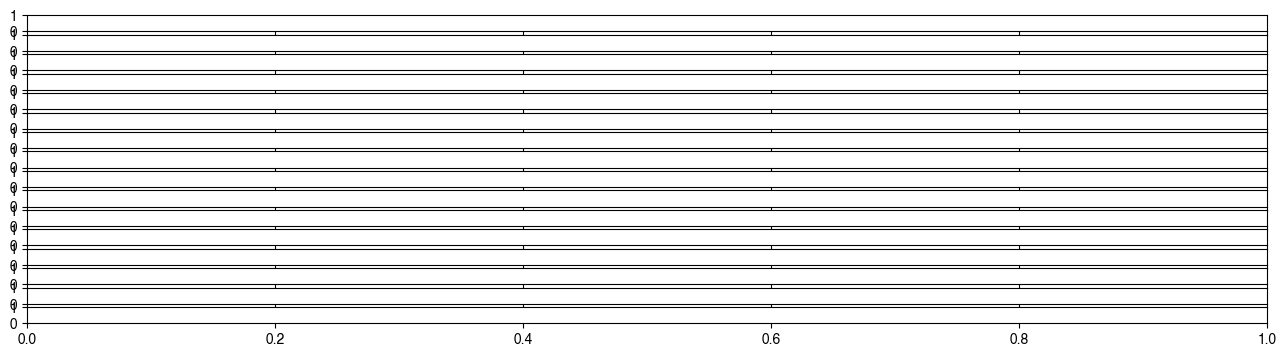

In [79]:
fig, axs = plt.subplots(len(sog1_orthologs["name"]), 1, figsize = (16,4), sharex = True)

for name, ax in zip(end_order, axs):
    if name == "BasicMaPo":
        last = True
    else:
        last = False

    #last = True
    plot_one_trace(name, ax, last)

axs[-1].text(x = 0, y = -23, va = "top", ha = "left", s = motif_align, color = sns.color_palette('tab10')[0])

plt.tight_layout(pad = 0)

In [ ]:
fig, axs = plt.subplots(3, 1, figsize = (12, 3), sharex = False)
axs[0].imshow(df,interpolation="gaussian", cmap = "Reds")
axs[0].set_yticks([]);

#x_label_list=['25', '300', '575', '850', '850', '575', '300', '25']

axs[0].set_xticks(np.arange(len(df.T)));
# axs[0].tick_params()
axs[0].set_xticklabels(df.T.index,rotation=90);


axs[1].imshow(heatmap_df[heatmap_df["Description_name"] == "BasicMaPo"][["normalized_Activity_S3_1"]].T,interpolation="quadric", cmap = "Reds")
axs[1].set_yticks([]);
axs[1].set_xticks(np.arange(len(heatmap_df[heatmap_df["Description_name"] == "BasicMaPo"])));
axs[1].set_xticklabels(heatmap_df[heatmap_df["Description_name"] == "BasicMaPo"].index,rotation=90);


axs[2].imshow(heatmap_df[heatmap_df["Description_name"] == "BasicSeMo"][["normalized_Activity_S3_1"]].T,interpolation="quadric", cmap = "Reds")
axs[2].set_yticks([]);

axs[2].set_xticks(np.arange(len(heatmap_df[heatmap_df["Description_name"] == "BasicSeMo"])));
axs[2].set_xticklabels(heatmap_df[heatmap_df["Description_name"] == "BasicSeMo"].index,rotation=90);


#sns.despine(left = True, bottom = True)
#ax.set_xticks(heatmap_df[heatmap_df["Description_name"] == "BasicArTh"].index);

In [ ]:
fig, axs = plt.subplots(3, 1, figsize = (12, 2), sharex = True)
axs[0].imshow(df,interpolation="gaussian", cmap = "Reds")
axs[0].set_yticks([]);

#x_label_list=['25', '300', '575', '850', '850', '575', '300', '25']

axs[0].set_xticks(np.arange(len(df.T)));
# axs[0].tick_params()
axs[0].set_xticklabels(df.T.index,rotation=90);


axs[1].imshow(heatmap_df[heatmap_df["Description_name"] == "BasicSeMo"][["normalized_Activity_S3_1"]].T,interpolation="quadric", cmap = "Reds")
axs[1].set_yticks([]);

axs[1].set_xticks(np.arange(len(heatmap_df[heatmap_df["Description_name"] == "BasicSeMo"])));
axs[1].set_xticklabels(heatmap_df[heatmap_df["Description_name"] == "BasicSeMo"].index,rotation=90);

axs[2].imshow(heatmap_df[heatmap_df["Description_name"] == "BasicMaPo"][["normalized_Activity_S3_1"]].T,interpolation="quadric", cmap = "Reds")
axs[2].set_yticks([]);

axs[2].set_xticks(np.arange(len(heatmap_df[heatmap_df["Description_name"] == "BasicMaPo"])));
axs[2].set_xticklabels(heatmap_df[heatmap_df["Description_name"] == "BasicMaPo"].index,rotation=90);

plt.tight_layout(pad = 0)
#sns.despine(left = True, bottom = True)
#ax.set_xticks(heatmap_df[heatmap_df["Description_name"] == "BasicArTh"].index);

In [ ]:
heatmap_df[heatmap_df["Description_name"] == "BasicMaPo"]

In [80]:
heatmap_df[heatmap_df["Description_name"] == "BasicBrRa"]#["normalized_Activity_S3_1"]].T

,Description_name,norm_activity_2
adj_mid,,
-410,BasicBrRa,0.028909
-400,BasicBrRa,NaN
-390,BasicBrRa,0.097204
-380,BasicBrRa,0.128834
-370,BasicBrRa,0.058186
-360,BasicBrRa,0.048189
-350,BasicBrRa,NaN
-340,BasicBrRa,0.213301
-330,BasicBrRa,0.113464


In [81]:
heatmap_df[heatmap_df["Description_name"] == "BasicArTh"][["normalized_Activity_S3_1"]].T

KeyError: "None of [Index(['normalized_Activity_S3_1'], dtype='object')] are in the [columns]"

In [ ]:
max_length = max(heatmap_df.index) - min(heatmap_df.index)
max_length

In [ ]:
heatmap_matrix = np.zeros((10,max_length))
heatmap_matrix